In [1]:
%pip install pykrige
%pip install xarray==2024.05.0

  Using cached pykrige-1.7.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.1 kB)
Using cached pykrige-1.7.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Note: you may need to restart the kernel to use updated packages.
  Using cached xarray-2024.5.0-py3-none-any.whl.metadata (11 kB)
Using cached xarray-2024.5.0-py3-none-any.whl (1.2 MB)
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.3.1
    Uninstalling xarray-2025.3.1:
      Successfully uninstalled xarray-2025.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires cf_xarray>=0.6.0, which is not installed.
xmip 0.7.2 requires xarrayutils, which is not installed.
xmip 0.7.2 requires xgcm<0.7.0, which is not installed.
Note: you may need to restart the kernel to use updated pa

In [2]:
%matplotlib widget

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
from skimage import exposure
from skimage.io import imsave, imread
from osgeo import ogr
import pystac_client
from pyproj import Transformer
from datetime import date, timedelta, datetime
from dateutil.relativedelta import relativedelta
import geopandas as gpd
import pandas as pd
import geoviews as gv
import hvplot.pandas
import intake
import xarray as xr
import numpy as np
from numpy.random import default_rng
import intake
from pyproj import Proj, transform
from osgeo import gdal
from sklearn.neighbors import BallTree
import earthaccess
import gzip

# for progress bar
from ipywidgets import IntProgress
from IPython.display import display
from ipywidgets import interact, Dropdown
import time
from tqdm.notebook import trange, tqdm

import boto3
import rasterio as rio
from rasterio.features import rasterize
from rasterio.session import AWSSession
import dask
import os
import rioxarray
from rasterio.enums import Resampling
from rasterio.warp import reproject
from rasterio.warp import Resampling as resample
import cartopy.crs as ccrs
import cartopy
from pykrige.ok import OrdinaryKriging
from sklearn.linear_model import LinearRegression, RANSACRegressor
from scipy.odr import Model, RealData, ODR
import scipy.odr as odr
import scipy
import statsmodels.formula.api as smf
from shapely.geometry.polygon import Polygon, Point
from shapely.geometry import box, shape
import pygmt
import gc
import pytz
import pyproj
import math
from pathlib import Path
from matplotlib.patches import Polygon as Pgon
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

import SSTutils as sut

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Coefficients for calibration
calib_m = 0.76 
calib_b = 0.55

In [4]:
# Authenticate for accessing NASA data (MODIS)
auth = earthaccess.login(strategy="netrc")

# If we are not authenticated
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

In [5]:
# Landsat STAC catalog location
url = 'https://landsatlook.usgs.gov/stac-server'

# Paths
basepath = Path('/home/jovyan/Landsat_SST_algorithm')
lsatpath = basepath / 'Data'
atmpath = lsatpath / 'AtmCorrection'
modout_path = lsatpath / 'MOD07_L2'

WV = 'Water_Vapor'

# For geopandas and tile plots
satellite = 'Landsat8'
collection = 'landsat-c2l1' # Landsat Collection 2, Level 1
colnm = ['landsat:wrs_path','landsat:wrs_row']

# Dataset paths
iqvalid_path = lsatpath / 'SST/Validation/iQuamIntercomp/'
iQpath = lsatpath / 'iQuam'
sealpath = lsatpath / 'seal_tags'
iq_geojson = lsatpath / f'{satellite}_iQuam.geojson'

svalid_path = lsatpath / 'SST/Validation/sealIntercomp/'
seal_geojson = lsatpath / f'{satellite}_sealtag.geojson'

# Seal tag data
seal_BASSTR = sealpath / 'BASSTR_v3_raw_and_interp.csv'
seal_IMOS = sealpath / 'IMOS_STR_v3_raw_and_interp.csv'

# Buffer around iquam point used to create a bounding box for Landsat sample
dist = 1.0 # km

# Temporal search range (days) before/after iquam measurement for finding Landsat image
time_add = 0.5

lthresh = -1.9

interp = 1

In [6]:
# Authenticate for boto S3 access, etc.
os.environ["AWS_REQUEST_PAYER"] = "requester"
aws_session = AWSSession(boto3.Session(), requester_pays=True)

In [7]:
# Setup and authenticate 
from dask.distributed import Client
import logging
client = Client(processes=True, n_workers=4, 
                threads_per_worker=1,
                silence_logs=logging.ERROR)
client.run(lambda: os.environ["AWS_REQUEST_PAYER"] == "requester" )
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/tsnow03/proxy/35391/status,
Dashboard: /user/tsnow03/proxy/35391/status,Workers: 4
Total threads: 4,Total memory: 29.08 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44063,Workers: 4
Dashboard: /user/tsnow03/proxy/35391/status,Total threads: 4
Started: Just now,Total memory: 29.08 GiB
Comm: tcp://127.0.0.1:45845,Total threads: 1
Dashboard: /user/tsnow03/proxy/39967/status,Memory: 7.27 GiB
Nanny: tcp://127.0.0.1:37193,


# Create validation matchups via GHRSST iQUAM data
https://www.star.nesdis.noaa.gov/socd/sst/iquam/?tab=0&dateinput_year=2023&dateinput_month=02&dayofmoninput_day=26&dateinput_hour=00&dayofmon=monthly&qcrefsst=_qcrey&qcrefsst=_qccmc&outlier=qced#qmap

In [8]:
# Year and months desired (multiple years)
start_yr = 2015
end_yr = 2016

# Note these will get months from the later part of the year to early next
start_mo = '09'
end_mo = '03'

# Headers for the saved outputs
headers = ['DateTime','L8_filename','L8_SST','L8_std','center','N','S','E','W','NE','SE','NW','SW','L8_SST_max','L8_SST_min','Argo_id','Argo_SST','Depth','platform_type','A_lat','A_lon']

# Desired projection transformation
source_crs = 'epsg:4326' 
target_crs = 'epsg:3031' # Coordinate system of the Landsat file

In [9]:
# # Create scalar for normalizing T, TOA, and WV data
months = ['01','02','03','04','05','06','07','08','09','10','11','12']

modtran_lut,n = sut.concat_modtran_months(months,atmpath)

simTOA = modtran_lut[['TOA T[K]']]
simWV = modtran_lut[['TCWV [cm]']]
# simT = modtran_lut[['Surface T[K]']] # Decided this was skewed because of Andy's forcings so use TOA scaler instead
simT = simTOA.rename(columns={'TOA T[K]': 'Surface T[K]'})

print(f'ERA5 count: {n}')
print(f'Simulated TOA min: {np.around(simTOA.min().values[0],2)}, and max: {np.around(simTOA.max().values[0],2)}')
print(f'Simulated WV min: {np.around(simWV.min().values[0],4)}, and max: {np.around(simWV.max().values[0],5)}')
print(f'Simulated SST min: {np.around(simT.min().values[0],2)}, and max: {np.around(simT.max().values[0],2)}')

simTOA_transformer = StandardScaler().fit(simTOA)
simWV_transformer = StandardScaler().fit(simWV)
# simT_transformer = RobustScaler().fit(simT)
simT_transformer = StandardScaler().fit(simT) # This is using TOA at the moment until get updated TOA

01: 1175
02: 1417
03: 1417
04: 1145
05: 958
06: 605
07: 515
08: 712
09: 327
10: 315
11: 314
12: 772
ERA5 count: 9672
Simulated TOA min: 270.17, and max: 275.18
Simulated WV min: 0.037, and max: 2.0716
Simulated SST min: 270.17, and max: 275.18


In [10]:
# Derive coefficients for SST retrievals
atmcor,retrieval_results,modtran_lut_norm = sut.derive_coeffs(atmpath,simTOA_transformer,simWV_transformer,simT_transformer)

Processing rolling window for middle month 01
12: 772
01: 1175
02: 1417
Rolling for month 01: toa = 1.08, tcwv_toa = -0.02, Intercept = 0.96, R2 = 0.98
p-values for month 01: toa = 0.0, tcwv_toa = 0.0, Intercept = 0.0
Processing rolling window for middle month 02
01: 1175
02: 1417
03: 1417
Rolling for month 02: toa = 1.08, tcwv_toa = -0.01, Intercept = 0.96, R2 = 0.98
p-values for month 02: toa = 0.0, tcwv_toa = 0.011, Intercept = 0.0
Processing rolling window for middle month 03
02: 1417
03: 1417
04: 1145
Rolling for month 03: toa = 1.07, tcwv_toa = 0.01, Intercept = 0.99, R2 = 0.99
p-values for month 03: toa = 0.0, tcwv_toa = 0.007, Intercept = 0.0
Processing rolling window for middle month 04
03: 1417
04: 1145
05: 958
Rolling for month 04: toa = 1.06, tcwv_toa = 0.01, Intercept = 0.99, R2 = 0.98
p-values for month 04: toa = 0.0, tcwv_toa = 0.0, Intercept = 0.0
Processing rolling window for middle month 05
04: 1145
05: 958
06: 605
Rolling for month 05: toa = 1.05, tcwv_toa = -0.0, In

In [12]:
%%time

# Multiple years

# Set up projections
transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)

# Get iQuam file paths in directory between desired dates and find and produce matching Landsat SSTs 
for year in range(start_yr, end_yr):  
    yrmo = []
    start_yrmo = f"{year}{start_mo}"  # Start from September of the current year
    end_yrmo = f"{year+1}{end_mo}"  # End in March of the next year

    m0 = start_yrmo
    
    # Make a list of months between start and end
    while int(m0) <= int(end_yrmo):
        calc_dt = datetime.strptime(f'{m0[:4]}-{m0[4:]}', '%Y-%m')
        yrmo.append(calc_dt.strftime("%Y%m"))
        m0 = (calc_dt + relativedelta(months=1)).strftime("%Y%m")
    
    # Get file names and select only those matching dates from yrmo    
    iQfiles = os.listdir(iQpath)
    iQfiles = [x for x in iQfiles if x[:6] in yrmo]
    iQfiles.sort(reverse=True)
    print (f'{year}: {len(iQfiles)}')
    
    os.chdir(iQpath)

    # For each iquam file, pair West Antarctic Argo buoy data with Landsat data and create calibrated SSTs
    valid = []
    
    for iquam_file in iQfiles:
        # Open Argos data from iQuam file
        df = xr.open_dataset(iquam_file)
        iquam = df.to_dataframe()
        
        # Subset to Antarctica
        ant = iquam[(iquam.lat<-65)&(iquam.lon>-142)&(iquam.lon<-72)&(iquam.quality_level==5.0)&(iquam.depth<6.0)]  # Entire West Antarctica (later) (iquam.platform_type==5.0)&
        # ant = iquam[(iquam.lat<-69)&(iquam.lon>-125)&(iquam.lon<-98)&(iquam.platform_type==5.0)&(iquam.quality_level==5.0)] # Amundsen Sea
        
        # To remove a landsat day that is coming up with a 403 error
        if ant['year'].iloc[0] == 2020 and ant['month'].iloc[0] == 12:
            ant = ant[ant.day != 9.0] # for 202012 because otherwise will fail
        
        print('')
        print(f'{iquam_file[:6]}: {ant.shape[0]} measurements')
    
        for idx in tqdm(range(ant.shape[0]), desc="Processing"):
    
            # Create search area
            ilat = ant['lat'].iloc[idx]
            ilon = ant['lon'].iloc[idx]
    
            lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
            lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
            bboxV = (ilon-lon_add,ilat-lat_add,ilon+lon_add,ilat+lat_add)
    
            # Create Landsat temporal search range in correct format
            ihr = int(ant.hour.iloc[idx])
            iyr = int(ant.year.iloc[idx])
            imo = int(ant.month.iloc[idx])
    
            calc_dt = datetime.strptime(f'{iyr}-{imo}-{int(ant.day.iloc[idx])} {ihr}', '%Y-%m-%d %H:%M:%SZ')
            start_dt = (calc_dt + timedelta(days=-time_add)).strftime('%Y-%m-%dT%H:%M:%SZ')
            end_dt = (calc_dt + timedelta(days=time_add)).strftime('%Y-%m-%dT%H:%M:%SZ')
    
            timeRangeV = f'{start_dt}/{end_dt}'
    
            # Search for desired Landsat scenes
            items = sut.search_stac(url,collection,gjson_outfile=iq_gjson,bbox=bboxV,timeRange=timeRangeV)
    
            # Load the geojson file and open stac catalog
            catalog = intake.open_stac_item_collection(items)
            gf = gpd.read_file(iq_gjson)
    
            # Exclude Landsat 9
            catalog_list = [x for x in items if x.id[3]=='8']
            num_scene = len(catalog_list)
            # print(f'{num_scene} Landsat 8 items')
    
            # If any matching landsat scenes are found create calibrated SSTs for them
            if num_scene>0:
    
                # Reproject to determine bounding box in espg 3031
                sbox,checkbox = sut.lsat_reproj(source_crs,target_crs,(bboxV[0],bboxV[1],bboxV[2],bboxV[3]))
    
                # Create polygon for later cropping
                polygon = Polygon([(sbox[0][0],sbox[0][1]),(sbox[3][0],sbox[3][1]),(sbox[2][0],sbox[2][1]),(sbox[1][0],sbox[1][1])])
                
                # Create min/max boundaries for trimming image before crop_xarray to cut down on processing times
                minx, miny, maxx, maxy = polygon.bounds
                polarx = [minx, maxx]
                polary = [miny, maxy]
    
                # Create calibrated SSTs for each matching landsat scene
                for sceneid in catalog_list:
                    print(sceneid.id)
    
                    scene = catalog[sceneid.id]
                    timestr = scene.metadata['datetime'].strftime('%H%M%S')
    
                    outFile = f'{iqvalid_path}/{sceneid.id}_{timestr}_Cel.tif'
    
                    if os.path.isfile(outFile):
                        print (f'{sceneid.id} - atm corr exists')
                        ls_scene = xr.open_dataset(outFile,chunks=dict(x=512, y=512),engine='rasterio')
                        ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)
    
                        # Subset all scenes and check for right dimensions because y order changes sometimes
                        ls_sub = sut.subset_img(ls_scene['band_data'].sel(band=1),polarx,polary) # subset so easier to work with
    
                    else:
                        # try:
                        # Open all desired bands for one scene
                        ls_scene = sut.landsat_to_xarray(sceneid,catalog)
                        ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)
        
                        # Create classification mask
                        ls_scene = sut.create_masks(ls_scene, cloud_mask=True, ice_mask=True, ocean_mask=True)

                        # Check for any open ocean pixels - go to next image if none - ??? s
                        mask = np.ones(ls_scene.shape[1:])
                        mask[ls_scene.mask!=3] = np.nan
                        ls_thermal = ls_scene.sel(band='lwir11').compute()

                        # Check in bounding box or for entire Landsat image depending on whether doing calibration runs or not
                        ls_box = sut.subset_img(ls_thermal*mask,polarx,polary)

                        if ((ls_box).notnull()).sum().values==0:
                            print (f'{sceneid.id} has no SSTs')
                            try:
                                del ls_scene, scene, mask, ls_thermal, ls_box
                            except:
                                pass
                            gc.collect()
                            continue

                        # Use band ratios for RF cloud pixel classification
                        ####

                        # Atmospheric correction using MODIS
                        # Acquire and align MODIS water vapor (MOD/MYD07) to Landsat
                        mod07,modfilenm = sut.open_MODIS(ls_scene,scene,modout_path)

                        # Create water vapor files aligned and subsampled to Landsat
                        spacing = [300,-300] # 300m sampling of MODIS data so that upsampling is easy and because 30m takes far too long
                        WV_xr = sut.get_wv(ls_scene,mod07,spacing,WV,scene,interp=interp)

                        # Create SST by masking and using water vapor to apply atmospheric correction
                        SST = sut.apply_retrieval(ls_thermal,scene,mask,WV_xr,atmcor,simT_transformer,simTOA_transformer,simWV_transformer)

                        # Record MODIS water vapor image used in atmospheric correction, will find this info save under band_data in
                        # data variables in COG (click on white paper info button in xarray readout)
                        SST.attrs['MODIS_WV'] = modfilenm

                        # Save to a cloud-optimized Geotiff
                        SST.rio.to_raster(raster_path=outFile, driver="COG")
                        print (f'Mean SST: {np.nanmean(SST)}')

                        # Subset all scenes and check for right dimensions because y order changes sometimes
                        ls_sub = sut.subset_img(SST,polarx,polary) # subset so easier to work with 

                        try:
                            del mask, ls_thermal, mod07, WV_xr, SST
                        except:
                            pass
    
                        # except Exception as e:
                        #     print (sceneid.id, e)
                        #     lsat = np.nan
                        #     lstd = np.nan
    
                    # Crop data to exact bounding box
                    ls_sub = sut.crop_xarray_dataarray_with_polygon(ls_sub, polygon) 
    
                    # Calibrate using MODIS
                    ls_sub = ls_sub * calib_m + calib_b
    
                    # Remove all pixels that are too cold
                    ls_sub = ls_sub.where(ls_sub>=lthresh,np.nan)
    
                    lsat = np.around(np.nanmean(ls_sub),2)
                    lstd = np.around(np.nanstd(ls_sub),2)
    
                    # Convert Argo lat/lon to Landsat's EPSG:3031
                    argo_px, argo_py = transformer.transform(ilon, ilat)
    
                    # Find the nearest center pixel
                    center_val = ls_sub.sel(x=argo_px, y=argo_py, method="nearest")
                    
                    # Extract the x/y coordinate values as plain floats
                    center_x = center_val.x.item()
                    center_y = center_val.y.item()
                    
                    # Get integer indices from the coordinate indexes
                    #    This uses ls_sub.get_index('dim_name') -> pandas.Index -> get_indexer(...)
                    center_x_idx = ls_sub.get_index("x").get_indexer([center_x])[0]
                    center_y_idx = ls_sub.get_index("y").get_indexer([center_y])[0]
                    
                    # Gather offsets for the 3x3 neighborhood
                    offsets = [
                        ( 0,  0, "center"),
                        ( 0,  1, "N"),
                        ( 0, -1, "S"),
                        ( 1,  0, "E"),
                        (-1,  0, "W"),
                        ( 1,  1, "NE"),
                        ( 1, -1, "SE"),
                        (-1,  1, "NW"),
                        (-1, -1, "SW"),
                    ]
                    
                    neighbors = {}
                    for dx, dy, name in offsets:
                        nx = center_x_idx + dx
                        ny = center_y_idx + dy
                        # Ensure we're within the array bounds
                        if (0 <= nx < ls_sub.sizes['x']) and (0 <= ny < ls_sub.sizes['y']):
                            # xarray dimension order is typically (y, x), so use isel(y=ny, x=nx):
                            neighbors[name] = ls_sub.isel(y=ny, x=nx).values.item()
                        else:
                            neighbors[name] = np.nan
                    
                    # Record coincident data from Landsat and Argo float
                    argo_temp = np.around((ant.sst.iloc[idx] - 273.15),2)  # convert to Celsius
                    times = pd.to_datetime(calc_dt, format='%Y%m%d%H%M%S')  # standardize time
                    
                    valid.append([
                        times,
                        sceneid.id,
                        lsat,
                        lstd,
                        neighbors['center'],
                        neighbors['N'],
                        neighbors['S'],
                        neighbors['E'],
                        neighbors['W'],
                        neighbors['NE'],
                        neighbors['SE'],
                        neighbors['NW'],
                        neighbors['SW'],
                        ls_sub.max().values.item(),
                        ls_sub.min().values.item(),
                        ant.iloc[idx].name,  # Argo ID or whichever label you prefer
                        argo_temp,
                        ant.iloc[idx].depth,
                        ant.iloc[idx].platform_type,
                        ilat,
                        ilon
                    ])
                    print (f'Argo temp: {argo_temp}, Landsat 8 mean: {lsat}+/-{lstd}')
    
                    try:
                        del ls_scene, scene, ls_thermal, ls_box, mod07, WV_xr, SST, ls_sub, neighbors
                    except:
                        pass
    
                    gc.collect()

    # Put data into DataFrame and save    
    lsat_mod_df = pd.DataFrame(valid,columns=headers)
    out_df = lsatpath / f'Landsat_validation_20250919_{start_yrmo}_{end_yrmo}_{dist}.csv'
    lsat_mod_df.to_csv(out_df)

2019: 7

202003: 77 measurements


Processing:  17%|█▋        | 13/77 [00:02<00:12,  4.96it/s]Skipping field instruments: unsupported OGR type: 5
Skipping field proj:shape: unsupported OGR type: 1
Skipping field proj:transform: unsupported OGR type: 1


LC08_L1GT_009109_20200329_20200822_02_T2
LC08_L1GT_009109_20200329_20200822_02_T2 - atm corr exists
Argo temp: -0.61, Landsat 8 mean: -1.12+/-0.17


Processing:  25%|██▍       | 19/77 [00:04<00:14,  4.06it/s]Skipping field instruments: unsupported OGR type: 5
Skipping field proj:shape: unsupported OGR type: 1
Skipping field proj:transform: unsupported OGR type: 1


LC08_L1GT_029110_20200309_20201016_02_T2
21 TOTAL granules
A granule has a problematic polygon that likely crosses the International DateLine
TopologyException: side location conflict at -48.129831600082028 -73.798472834150317. This can occur if the input geometry is invalid.
5 TOTAL granules w overlap
Time difference between MODIS and Landsat: 0 days 00:33:35


...

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

surface [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values
surface [WARNING]: Your grid dimensions are mutually prime.  Convergence is very unlikely.
surface [WARNING]: 3510 unusable points were supplied; these will be ignored.
surface [WARNING]: You should have pre-processed the data with block-mean, -median, or -mode.
surface [WARNING]: Check that previous processing steps write results with enough decimals.
surface [WARNING]: Possibly some data were half-way between nodes and subject to IEEE 754 rounding.


1
2
Mean water vapor value is: 0.4439287945462666, min: 0.33854, max: 0.50846
Mean SST: -2.465980154242375
Argo temp: -0.9, Landsat 8 mean: -0.93+/-0.05


Processing: 100%|██████████| 77/77 [02:17<00:00,  1.79s/it]


CPU times: user 1min 42s, sys: 8.93 s, total: 1min 51s
Wall time: 2min 26s


# Create validation matchups via TARSAN seal tag data

In [3]:
        # Not using these at all
        # # neighbors = {
        # #     "center": center_value,
        # # }
        
        # # # Get coordinate spacing
        # # x_coords = SST_sub.x.values
        # # y_coords = SST_sub.y.values
        
        # # # Find indices
        # # x_idx = np.where(x_coords == center_x)[0][0]
        # # y_idx = np.where(y_coords == center_y)[0][0]
        
        # # # Neighbor offsets
        # # neighbor_offsets = {
        # #     "N": (0, 1), "S": (0, -1), "E": (1, 0), "W": (-1, 0),
        # #     "NE": (1, 1), "SE": (1, -1), "NW": (-1, 1), "SW": (-1, -1)
        # # }
        
        # # for name, (dx, dy) in neighbor_offsets.items():
        # #     nx, ny = x_idx + dx, y_idx + dy
        # #     if 0 <= nx < len(x_coords) and 0 <= ny < len(y_coords):
        # #         val = SST_sub.isel(x=nx, y=ny)
        # #         if isinstance(val, xr.Dataset):
        # #             neighbors[name] = float(val['band_data'].values.item())
        # #         else:
        # #             neighbors[name] = float(val.values.item())
        # #     else:
        # #         neighbors[name] = np.nan

            # neighbors['N'],
            # neighbors['S'],
            # neighbors['E'],
            # neighbors['W'],
            # neighbors['NE'],
            # neighbors['SE'],
            # neighbors['NW'],
            # neighbors['SW'],

# _____

        # # Create search area around THIS specific seal point (in lat/lon)
        # ilat = row[lat_nm]
        # ilon = row[lon_nm]
        # lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
        # lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
        
        # # Create bounding box in lat/lon
        # bboxV = (ilon-lon_add, ilat-lat_add, ilon+lon_add, ilat+lat_add)
        
        # # Reproject bounding box to EPSG:3031
        # sbox, checkbox = sut.lsat_reproj(source_crs, target_crs, 
        #                                   (bboxV[0], bboxV[1], bboxV[2], bboxV[3]))
        
        # # Create polygon for cropping
        # polygon = Polygon([(sbox[0][0],sbox[0][1]), (sbox[3][0],sbox[3][1]), 
        #                   (sbox[2][0],sbox[2][1]), (sbox[1][0],sbox[1][1])])
        
        # # Get min/max boundaries
        # minx, miny, maxx, maxy = polygon.bounds
        # polarx = [minx, maxx]
        # polary = [miny, maxy]
        
        # # Subset to the small area around this seal point
        # SST_sub = sut.subset_img(SST_calibrated, polarx, polary)
        
        # # Crop to exact polygon
        # SST_sub = sut.crop_xarray_dataarray_with_polygon(SST_sub, polygon)
        
        # # Now compute statistics for THIS specific area
        # lsat = np.around(np.nanmean(SST_sub), 2)
        # lstd = np.around(np.nanstd(SST_sub), 2)

# -----
# # Get center pixel value
        # center_val = SST_sub.sel(x=x_pt, y=y_pt, method="nearest")
        
        # # Extract the x/y coordinate values as plain floats
        # center_x = float(center_val.x.values)
        # center_y = float(center_val.y.values)
        
        # # Extract the actual value
        # if isinstance(center_val, xr.Dataset):
        #     center_value = float(center_val['band_data'].values.item())
        # else:
        #     center_value = float(center_val.values.item())

In [32]:
# Landsat STAC catalog location
url = 'https://landsatlook.usgs.gov/stac-server'

# Paths
basepath = Path('/home/jovyan/Landsat_SST_algorithm')
lsatpath = basepath / 'Data'
atmpath = lsatpath / 'AtmCorrection'
modout_path = lsatpath / 'MOD07_L2'
svalid_path = lsatpath / 'SST/Validation/sealIntercomp/'
sealpath = lsatpath / 'seal_tags'

WV = 'Water_Vapor'

# For geopandas and tile plots
satellite = 'Landsat8'
collection = 'landsat-c2l1' # Landsat Collection 2, Level 1
colnm = ['landsat:wrs_path','landsat:wrs_row']
seal_geojson = lsatpath / f'{satellite}_sealtag.geojson'

# Seal tag data
seal_BASSTR = sealpath / 'BASSTR_v3_raw_and_interp.csv'
seal_IMOS = sealpath / 'IMOS_STR_v3_raw_and_interp.csv'

# Buffer around iquam point used to create a bounding box for Landsat sample
dist = 5.0 # km

# Temporal search range (days) before/after iquam measurement for finding Landsat image
time_add = 0.5

lthresh = -1.9

interp = 1

#***Choose which dataset to process here
# dataset = 'IMOS'
dataset = 'BASSTR'

In [27]:
# Authenticate for accessing NASA data (MODIS)
auth = earthaccess.login(strategy="netrc")

# If we are not authenticated
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

In [10]:
# Authenticate for boto S3 access, etc.
os.environ["AWS_REQUEST_PAYER"] = "requester"
aws_session = AWSSession(boto3.Session(), requester_pays=True)

In [11]:
# Setup and authenticate 
from dask.distributed import Client
import logging
client = Client(processes=True, n_workers=4, 
                threads_per_worker=1,
                silence_logs=logging.ERROR)
client.run(lambda: os.environ["AWS_REQUEST_PAYER"] == "requester" )
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/tsnow03/proxy/39125/status,
Dashboard: /user/tsnow03/proxy/39125/status,Workers: 4
Total threads: 4,Total memory: 29.08 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42317,Workers: 4
Dashboard: /user/tsnow03/proxy/39125/status,Total threads: 4
Started: Just now,Total memory: 29.08 GiB
Comm: tcp://127.0.0.1:39633,Total threads: 1
Dashboard: /user/tsnow03/proxy/37101/status,Memory: 7.27 GiB
Nanny: tcp://127.0.0.1:45319,


In [12]:
# # Year and months desired (multiple years)
# start_yr = 2019
# end_yr = 2022

# # Note these will get months from the later part of the year to early next
# start_mo = '01'
# end_mo = '12'

# Headers for the saved outputs
# headers = ['DateTime','L8_filename','L8_SST','L8_std','center','N','S','E','W','NE','SE','NW','SW','L8_SST_max','L8_SST_min','seal_id','seal_SST','Depth','platform_type','A_lat','A_lon']
headers = ['DateTime','L8_filename','L8_SST','L8_std','center','L8_SST_max','L8_SST_min','L8_SST_ani','L8_std_ani','center_ani','seal_id','seal_SST',
           'rawT_header','depth','seal_interp_SST','interpT_header','interp_depth','platform_type','A_lat','A_lon','A_lat_ani','A_lon_ani','loc_err',
           'qc[x_y_xse_yse]','time_dif']
# Desired projection transformation
source_crs = 'epsg:4326' 
target_crs = 'epsg:3031' # Coordinate system of the Landsat file

In [13]:
output_path = sealpath / f"{seal_BASSTR.stem}_clean.csv"

if os.path.isfile(output_path):
    sealB = pd.read_csv(output_path,parse_dates=['Date'])
else:
    sealB = pd.read_csv(seal_BASSTR,parse_dates=True)
    
    cols_to_split = [
        'LATITUDE_AniMotum', 'LONGTITUDE_AniMotum',
           'Argos_Error_Radius', 'LONGITUDE_Argos', 'LATITUDE_Argos', 'POSITION_QC_Argos', 
           'qc_ssm_x', 'qc_ssm_y', 'qc_ssm_x_se', 'qc_ssm_y_se',
           'CT_raw_bin1', 'CT_raw_bin2', 'CT_raw_bin3', 'CT_raw_bin4',
           'SA_raw_bin1', 'SA_raw_bin2', 'SA_raw_bin3', 'SA_raw_bin4',
           'Pres_raw_bin1', 'Pres_raw_bin2', 'Pres_raw_bin3', 'Pres_raw_bin4',
           'Date', 'CT_interp_1m', 'CT_interp_2m', 'CT_interp_3m', 'CT_interp_4m',
           'CT_interp_5m', 'CT_interp_6m', 'CT_interp_7m', 'CT_interp_8m',
           'CT_interp_9m', 'CT_interp_10m'
    ]
    
    # Split comma-separated strings into lists
    for c in cols_to_split:
        sealB[c] = sealB[c].astype(str).str.split(',')
        print(len(sealB[c]))
    
    # Expand each list into its own row
    sealB = sealB.explode(cols_to_split, ignore_index=True)
    for c in cols_to_split:
        if c == 'Date':
            sealB[c] = sealB[c].str.replace(r"[\[\]'\" ]", "", regex=True).replace({'null': np.nan, 'None': np.nan, '': np.nan})
        else:
            sealB[c] = pd.to_numeric(sealB[c].str.replace(r"[\[\]'\" ]", "", regex=True).replace({'null': np.nan, 'None': np.nan, '': np.nan}))
            
    
    # Convert Date to datetime and set as index
    sealB['Date'] = pd.to_datetime(sealB['Date'], format='%y-%m-%dT%H:%M:%S')
    sealB = sealB.sort_values('Date').reset_index(drop=True)
    
    nat = sealB['CT_interp_1m'].isna().sum()
    print(f'{nat} T are null')
    
    # Save or inspect
    sealB.to_csv(output_path, index=False)

sealB.tail()

,LATITUDE_AniMotum,LONGTITUDE_AniMotum,smru_platform_code,species,Argos_Error_Radius,LONGITUDE_Argos,POSITION_QC_Argos,LATITUDE_Argos,qc_ssm_x,qc_ssm_y,...,SA_interp_1m,SA_interp_2m,SA_interp_3m,SA_interp_4m,SA_interp_5m,SA_interp_6m,SA_interp_7m,SA_interp_8m,SA_interp_9m,SA_interp_10m
13597,-71.251726,-109.333384,ct153-Pendragon-19,Weddell seal,NaN,-109.319342,9,-71.265701,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."
13598,-71.190332,-109.362434,ct153-Pendragon-19,Weddell seal,NaN,-109.437860,0,-71.172776,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."
13599,-71.199024,-109.400410,ct153-Pendragon-19,Weddell seal,NaN,-109.399135,9,-71.200021,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."
13600,-71.176959,-109.402721,ct153-Pendragon-19,Weddell seal,NaN,-109.342734,9,-71.169624,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."
13601,-71.175979,-109.401530,ct153-Pendragon-19,Weddell seal,NaN,-109.333412,9,-71.167207,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."


In [14]:
output_path = sealpath / f"{seal_IMOS.stem}_clean.csv"

if os.path.isfile(output_path):
    sealI = pd.read_csv(output_path,parse_dates=['Date'])
else:
    sealI = pd.read_csv(seal_IMOS,parse_dates=True)
    
    # sealI.columns
    cols_to_split = [
        'LATITUDE_Argos', 'LONGITUDE_Argos', 'Argos_Error_Radius', 'LATITUDE_AniMotum', 'LONGTITUDE_AniMotum',
           'qc_ssm_x', 'qc_ssm_y', 'qc_ssm_x_se', 'qc_ssm_y_se', 'CT_interp_1m',
           'CT_interp_2m', 'CT_interp_3m', 'CT_interp_4m', 'CT_interp_5m',
           'CT_interp_6m', 'CT_interp_7m', 'CT_interp_8m', 'CT_interp_9m',
           'CT_interp_10m', 'SA_interp_1m', 'SA_interp_2m', 'SA_interp_3m',
           'SA_interp_4m', 'SA_interp_5m', 'SA_interp_6m', 'SA_interp_7m',
           'SA_interp_8m', 'SA_interp_9m', 'SA_interp_10m', 'CT_raw_bin1',
           'CT_raw_bin2', 'CT_raw_bin3', 'CT_raw_bin4', 'SA_raw_bin1',
           'SA_raw_bin2', 'SA_raw_bin3', 'SA_raw_bin4', 'Pres_raw_bin1',
           'Pres_raw_bin2', 'Pres_raw_bin3', 'Pres_raw_bin4','Date'
    ]
    
    # Split comma-separated strings into lists
    for c in cols_to_split:
        sealI[c] = sealI[c].astype(str).str.split(',')
    
    # Expand each list into its own row
    sealI = sealI.explode(cols_to_split, ignore_index=True)
    for c in cols_to_split:
        if c == 'Date':
            sealI[c] = sealI[c].str.replace(r"[\[\]'\" ]", "", regex=True).replace({'null': np.nan, 'None': np.nan, '': np.nan})
        else:
            sealI[c] = pd.to_numeric(sealI[c].str.replace(r"[\[\]'\" ]", "", regex=True).replace({'null': np.nan, 'None': np.nan, '': np.nan}))
    
    # Convert Date to datetime and set as index
    sealI['Date'] = pd.to_datetime(sealI['Date'], format='%y-%m-%dT%H:%M:%S')
    sealI = sealI.sort_values('Date').reset_index(drop=True)
    
    print (f'{sealI.shape[0]} dives')
    nat = sealI['CT_interp_1m'].isna().sum()
    nas = sealI['SA_interp_1m'].isna().sum()
    print(f'{nas} S, {nat} T are null')
    
    # Save or inspect
    sealI.to_csv(output_path, index=False)

sealI.head()

,LATITUDE_Argos,LONGITUDE_Argos,smru_platform_code,species,Argos_Error_Radius,LATITUDE_AniMotum,LONGTITUDE_AniMotum,qc_ssm_x,qc_ssm_y,qc_ssm_x_se,...,CT_raw_bin4,SA_raw_bin1,SA_raw_bin2,SA_raw_bin3,SA_raw_bin4,Pres_raw_bin1,Pres_raw_bin2,Pres_raw_bin3,Pres_raw_bin4,Date
0,-49.2212,71.6199,ct144-F620BAT-17,Southern elephant seal,2534.909279,-49.2296,71.6347,131.7741,4617.2654,1.6200,...,2.046670,34.148390,34.149629,34.150596,34.151880,4,10.0,20.0,50.0,2018-10-14 14:40:00
1,-49.0886,71.9225,ct144-F620BAT-17,Southern elephant seal,3747.384585,-49.0945,71.9696,159.3294,4633.0381,1.3448,...,1.737732,34.146785,34.147939,34.148878,34.150277,4,10.0,20.0,50.0,2018-10-14 21:10:00
2,-49.0512,72.3769,ct144-F620BAT-17,Southern elephant seal,3927.514720,-49.0554,72.3573,190.8709,4636.6756,1.9645,...,2.004849,34.127114,34.129586,34.131181,34.133306,4,10.0,20.0,50.0,2018-10-15 04:40:00
3,-49.0635,72.6454,ct144-F620BAT-17,Southern elephant seal,4208.870109,-49.0691,72.6495,214.4396,4633.9501,3.3174,...,1.994698,34.138642,34.138810,34.138804,34.139207,4,10.0,20.0,50.0,2018-10-15 11:09:59
4,-49.0677,72.7350,ct144-F620BAT-17,Southern elephant seal,5820.315338,-49.0687,72.7415,221.8832,4633.6543,2.3144,...,2.008061,34.130388,34.131771,34.132872,34.134784,4,10.0,20.0,50.0,2018-10-15 13:19:59


In [15]:
# # Create scalar for normalizing T, TOA, and WV data
months = ['01','02','03','04','05','06','07','08','09','10','11','12']

modtran_lut,n = sut.concat_modtran_months(months,atmpath)

simTOA = modtran_lut[['TOA T[K]']]
simWV = modtran_lut[['TCWV [cm]']]
# simT = modtran_lut[['Surface T[K]']] # Decided this was skewed because of Andy's forcings so use TOA scaler instead
simT = simTOA.rename(columns={'TOA T[K]': 'Surface T[K]'})

print(f'ERA5 count: {n}')
print(f'Simulated TOA min: {np.around(simTOA.min().values[0],2)}, and max: {np.around(simTOA.max().values[0],2)}')
print(f'Simulated WV min: {np.around(simWV.min().values[0],4)}, and max: {np.around(simWV.max().values[0],5)}')
print(f'Simulated SST min: {np.around(simT.min().values[0],2)}, and max: {np.around(simT.max().values[0],2)}')

simTOA_transformer = StandardScaler().fit(simTOA)
simWV_transformer = StandardScaler().fit(simWV)
# simT_transformer = RobustScaler().fit(simT)
simT_transformer = StandardScaler().fit(simT) # This is using TOA at the moment until get updated TOA

01: 1175
02: 1417
03: 1417
04: 1145
05: 958
06: 605
07: 515
08: 712
09: 327
10: 315
11: 314
12: 772
ERA5 count: 9672
Simulated TOA min: 270.17, and max: 275.18
Simulated WV min: 0.037, and max: 2.0716
Simulated SST min: 270.17, and max: 275.18


In [16]:
# Derive coefficients for SST retrievals
atmcor,retrieval_results,modtran_lut_norm = sut.derive_coeffs(atmpath,simTOA_transformer,simWV_transformer,simT_transformer)

Processing rolling window for middle month 01
12: 772
01: 1175
02: 1417
Rolling for month 01: toa = 1.08, tcwv_toa = -0.02, Intercept = 0.96, R2 = 0.98
p-values for month 01: toa = 0.0, tcwv_toa = 0.0, Intercept = 0.0
Processing rolling window for middle month 02
01: 1175
02: 1417
03: 1417
Rolling for month 02: toa = 1.08, tcwv_toa = -0.01, Intercept = 0.96, R2 = 0.98
p-values for month 02: toa = 0.0, tcwv_toa = 0.011, Intercept = 0.0
Processing rolling window for middle month 03
02: 1417
03: 1417
04: 1145
Rolling for month 03: toa = 1.07, tcwv_toa = 0.01, Intercept = 0.99, R2 = 0.99
p-values for month 03: toa = 0.0, tcwv_toa = 0.007, Intercept = 0.0
Processing rolling window for middle month 04
03: 1417
04: 1145
05: 958
Rolling for month 04: toa = 1.06, tcwv_toa = 0.01, Intercept = 0.99, R2 = 0.98
p-values for month 04: toa = 0.0, tcwv_toa = 0.0, Intercept = 0.0
Processing rolling window for middle month 05
04: 1145
05: 958
06: 605
Rolling for month 05: toa = 1.05, tcwv_toa = -0.0, In

In [ ]:
%%time
if dataset == 'IMOS'
    sdata = sealI
elif dataset == 'BASSTR'
    sdata = sealB

# Find all seal tag matchups
vkind = 'seal'

lat_nm = 'LATITUDE_Argos'
lon_nm = 'LONGITUDE_Argos'
lat_ani = 'LATITUDE_AniMotum'
lon_ani = 'LONGTITUDE_AniMotum'
loc_err = 'Argos_Error_Radius'
qc_err1 = 'qc_ssm_x'
qc_err2 = 'qc_ssm_y' 
qc_err3 = 'qc_ssm_x_se'
qc_err4 = 'qc_ssm_y_se'
tdif = 'time_diff'
T_nm = 'CT_raw_bin1'
depth_nm = 'Pres_raw_bin1'
Tint_nm = 'CT_interp_1m'
depthint_nm = 1
convertC = 0 # already in C
platform_nm = 'smru_platform_code'
id_nm = 'Date'
date_nm = 'Date'

# Set up projections
transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)


# Subset seals to Antarctica as before
ant = sdata[(sdata[lat_nm] < -65)]
# ant = sdata[(sdata[lat_nm] < -65) & (sdata[lon_nm] > -142) & (sdata[lon_nm] < -72)]

# Overall spatial bounds (pad by a bit to be safe)
lon_min = ant[lon_nm].min() - 1
lon_max = ant[lon_nm].max() + 1
lat_min = ant[lat_nm].min() - 1
lat_max = ant[lat_nm].max() + 1
bbox_global = (lon_min, lat_min, lon_max, lat_max)

# Overall time bounds (add your ± time_add)
dt_min = ant[date_nm].min() - pd.Timedelta(days=time_add)
dt_max = ant[date_nm].max() + pd.Timedelta(days=time_add)
timeRange_global = f"{dt_min.strftime('%Y-%m-%dT%H:%M:%SZ')}/{dt_max.strftime('%Y-%m-%dT%H:%M:%SZ')}"

# ONE STAC search for all Landsat scenes
items = sut.search_stac(
    url,
    collection,
    gjson_outfile=seal_geojson,
    bbox=bbox_global,
    timeRange=timeRange_global,
)

# Open catalog once
catalog = intake.open_stac_item_collection(items)

# Build a GeoDataFrame of candidate scenes (Landsat 8 only)
scenes = []
for it in items:
    if it.id[3] != "8":
        continue
    scenes.append({
        "sceneid": it.id,
        "datetime": it.datetime,   # or it.properties["datetime"]
        "geometry": shape(it.geometry),
    })

scene_gdf = gpd.GeoDataFrame(scenes, geometry="geometry", crs="EPSG:4326")

# Sort by datetime
scene_gdf = scene_gdf.sort_values(by='datetime').reset_index(drop=True)
scene_gdf.head()

In [18]:
%%time

# --- Make sure seal data has naive datetimes ---
seal_gdf = gpd.GeoDataFrame(
    ant.copy(),
    geometry=gpd.points_from_xy(ant[lon_nm], ant[lat_nm]),
    crs="EPSG:4326",
)

# Seal timestamps: force tz-naive
seal_gdf[date_nm] = pd.to_datetime(seal_gdf[date_nm], errors="coerce")
seal_gdf[date_nm] = seal_gdf[date_nm].dt.tz_localize(None)

# --- Ensure scene datetimes are tz-naive ---
scene_gdf = scene_gdf.copy()
scene_gdf["datetime"] = pd.to_datetime(scene_gdf["datetime"], errors="coerce")
scene_gdf["datetime"] = scene_gdf["datetime"].dt.tz_localize(None)

# --- Spatial join to find which seals fall within which scene footprints ---
pairs = gpd.sjoin(
    seal_gdf,
    scene_gdf,
    how="inner",
    predicate="intersects",
)

# ----------------------------------------------
# Temporal filtering: keep only ±12 hours matches
# ----------------------------------------------

# Compute absolute time differences (now both tz-naive → no errors)
pairs[tdif] = (pairs[date_nm] - pairs["datetime"]).abs()

# Keep only seals within ±12 hours (adjust as needed)
pairs = pairs[pairs[tdif] <= pd.Timedelta(hours=12)]

print("Number of seal–scene matches:", len(pairs))
print(pairs.head())

Number of seal–scene matches: 2697
   LATITUDE_AniMotum  LONGTITUDE_AniMotum smru_platform_code  \
0         -73.867660          -103.002670       ct147-863-18   
2         -73.665021          -103.162430       ct147-867-18   
3         -73.704176          -103.182663       ct147-867-18   
4         -73.737938          -103.122527       ct147-870-18   
5         -73.736265          -102.995912       ct147-870-18   

                  species  Argos_Error_Radius  LONGITUDE_Argos  \
0  Southern elephant seal         3388.246627      -103.004259   
2            Weddell seal         1878.928310      -103.155140   
3            Weddell seal         2252.668353      -103.122409   
4            Weddell seal         1307.380026      -103.130276   
5            Weddell seal         4259.330841      -102.984035   

   POSITION_QC_Argos  LATITUDE_Argos      qc_ssm_x      qc_ssm_y  ...  \
0                  0      -73.867587 -1.146620e+07 -1.242121e+07  ...   
2                  0      -73.664004 

In [19]:
def sub_to_point(row, lat_nm, lon_nm, dist, source_crs, target_crs, SST_calibrated):
    # Create search area around THIS specific seal point (in lat/lon)
    ilat = row[lat_nm]
    ilon = row[lon_nm]
    lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
    lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
    
    # Create bounding box in lat/lon
    bboxV = (ilon-lon_add, ilat-lat_add, ilon+lon_add, ilat+lat_add)
    
    # Reproject bounding box to EPSG:3031
    sbox, checkbox = sut.lsat_reproj(source_crs, target_crs, 
                                      (bboxV[0], bboxV[1], bboxV[2], bboxV[3]))
    
    # Create polygon for cropping
    polygon = Polygon([(sbox[0][0],sbox[0][1]), (sbox[3][0],sbox[3][1]), 
                      (sbox[2][0],sbox[2][1]), (sbox[1][0],sbox[1][1])])
    
    # Get min/max boundaries
    minx, miny, maxx, maxy = polygon.bounds
    polarx = [minx, maxx]
    polary = [miny, maxy]
    
    # Subset to the small area around this seal point
    SST_sub = sut.subset_img(SST_calibrated, polarx, polary)
    
    # Crop to exact polygon
    SST_sub = sut.crop_xarray_dataarray_with_polygon(SST_sub, polygon)
    
    # Now compute statistics for THIS specific area
    lsat = np.around(np.nanmean(SST_sub), 2)
    lstd = np.around(np.nanstd(SST_sub), 2)

    return lsat, lstd, SST_sub

def center_pix(SST_sub, x_pt, y_pt):
    # Get center pixel value
    center_val = SST_sub.sel(x=x_pt, y=y_pt, method="nearest")
    
    # Extract the x/y coordinate values as plain floats
    center_x = float(center_val.x.values)
    center_y = float(center_val.y.values)
    
    # Extract the actual value
    if isinstance(center_val, xr.Dataset):
        center_value = float(center_val['band_data'].values.item())
    else:
        center_value = float(center_val.values.item())


In [20]:
# # LC08_L1GT_232113_20200323_20200822_02_T2

# grouped = list(pairs.groupby("sceneid"))
# for sceneid, group in tqdm(grouped[284:290], desc="Processing"): 
#     print(sceneid)

In [ ]:
valid = []

# Before the loop, create a dictionary mapping scene IDs to STAC items
item_dict = {item.id: item for item in items if item.id[3] == '8'}

# pairs = pairs.sort_values(by='datetime')  # Sort by scene datetime

# for sceneid, group in tqdm(pairs.groupby("sceneid"), desc="Processing"):
grouped = list(pairs.groupby("sceneid"))
try:
    for sceneid, group in tqdm(grouped[287:], desc="Processing"): 
        # Vectorized transform of ALL associated seal points to EPSG:3031
        lons = group[lon_nm].to_numpy()
        lats = group[lat_nm].to_numpy()
        xs, ys = transformer.transform(lons, lats)  # arrays, not scalar
        
        # Get the STAC item object
        item = item_dict[sceneid]
        
        scene = catalog[sceneid]
        timestr = scene.metadata['datetime'].strftime('%H%M%S')
        outFile = f'{svalid_path}/{sceneid}_{timestr}_Cel.tif'
    
        # Either open existing SST COG, or create it once
        if os.path.isfile(outFile):
            print(f"{sceneid} - atm corr exists")
            SST = xr.open_dataset(outFile, chunks=dict(x=512, y=512), engine="rasterio")["band_data"]
            SST = SST.rio.write_crs("epsg:3031", inplace=True)
        else:
            print(f"{sceneid}")
            # Pass the STAC item object, not the string ID
            ls_scene = sut.landsat_to_xarray(item, catalog)
            ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)
            ls_scene = sut.create_masks(ls_scene, cloud_mask=True, ice_mask=True, ocean_mask=True)
    
            mask = np.ones(ls_scene.shape[1:])
            mask[ls_scene.mask != 3] = np.nan
            ls_thermal = ls_scene.sel(band="lwir11").compute()
    
            # For speed, optionally subset thermal to a bbox around seal tag points and check for valid pixels
            minx, maxx = xs.min(), xs.max()
            miny, maxy = ys.min(), ys.max()
            thermal_check = sut.subset_img(ls_thermal, [minx, maxx], [miny, maxy])  # like you already do
            
            if np.all(np.isnan(thermal_check)):
                print(f'{sceneid} has no valid SST values in seal tag region')
                continue
    
            # Use band ratios for RF cloud pixel classification
            ####
            
            # Atmospheric correction using MODIS
            # Acquire and align MODIS water vapor (MOD/MYD07) to Landsat
            mod07, modfilenm = sut.open_MODIS(ls_scene, scene, modout_path)
    
            # Create water vapor files aligned and subsampled to Landsat
            spacing = [300, -300] # 300m sampling of MODIS data so that upsampling is easy and because 30m takes far too long
            WV_xr = sut.get_wv(ls_scene, mod07, spacing, WV, scene, interp=interp)
    
            # Create SST by masking and using water vapor to apply atmospheric correction
            SST = sut.apply_retrieval(ls_thermal, scene, mask, WV_xr, atmcor, simT_transformer, simTOA_transformer, simWV_transformer)
            
            # Record MODIS water vapor image used in atmospheric correction
            SST.attrs["MODIS_WV"] = modfilenm
    
            # Save to a cloud-optimized Geotiff
            SST.rio.to_raster(raster_path=outFile, driver="COG")
            print (f'Mean SST: {np.nanmean(SST)}')
    
        if np.all(np.isnan(SST)):
            print(f'{sceneid} has no valid SST values')
            continue
    
        # For this scene, now have: SST in EPSG:3031
        
        # Apply calibration and thresholds to the full scene
        SST_calibrated = SST * calib_m + calib_b
        SST_calibrated = SST_calibrated.where(SST_calibrated >= lthresh, np.nan)
    
        # Extract nearest pixel for each seal
        for (idx, row), x_pt, y_pt in zip(group.iterrows(), xs, ys):
    
            # Create search area around THIS specific seal point (in lat/lon) and its Animotum location
            lsat, lstd, SST_sub = sub_to_point(row, lat_nm, lon_nm, dist, source_crs, target_crs, SST_calibrated)
            lsat_ani, lstd_ani, SST_sub_ani = sub_to_point(row, lat_ani, lon_ani, dist, source_crs, target_crs, SST_calibrated)
            
            # Get center pixel value
            center_value = center_pix(SST_sub, x_pt, y_pt)
            center_value_ani = center_pix(SST_sub_ani, x_pt, y_pt)
    
            argo_temp = np.around(row[T_nm] - convertC, 2)
            argo_temp_interp = np.around(row[Tint_nm] - convertC, 2)
    
            valid.append([
                row[date_nm],
                sceneid,
                lsat,
                lstd,
                center_value,
                SST_sub.max().values.item(),
                SST_sub.min().values.item(),
                lsat_ani,
                lstd_ani,
                center_value_ani,
                f'{row[platform_nm]}-{row[date_nm]}',
                argo_temp,
                T_nm,
                row[depth_nm],
                argo_temp_interp,
                Tint_nm,
                depthint_nm,
                row[platform_nm],
                row[lat_nm],
                row[lon_nm],
                row[lat_ani],
                row[lon_ani],
                row[loc_err],
                [row[qc_err1],row[qc_err2],row[qc_err3],row[qc_err4]],
                row[tdif],
            ])
            print (f'Argo temp: {argo_temp}, Landsat 8 mean: {lsat}+/-{lstd}, Lsat Animotum mean: {lsat_ani}+/-{lstd_ani}')
    
        try:
            del ls_scene, scene, ls_thermal, thermal_check, mod07, WV_xr, SST, SST_calibrated, SST_sub
        except:
            pass
    
        gc.collect()
except:
    pass
    
# Put data into DataFrame and save    
lsat_mod_df = pd.DataFrame(valid,columns=headers)
out_df = lsatpath / f'Landsat_{vkind}{dataset}_validation_20260116_alltime_{dist}.csv'
lsat_mod_df.to_csv(out_df)

Processing:   0%|          | 0/18 [00:00<?, ?it/s]

LC08_L1GT_232114_20190711_20200827_02_T2


Processing:   6%|▌         | 1/18 [00:22<06:26, 22.75s/it]

LC08_L1GT_232114_20190711_20200827_02_T2 has no valid SST values in seal tag region
LC08_L1GT_233113_20190224_20201016_02_T2 - atm corr exists


Processing:  11%|█         | 2/18 [00:25<02:53, 10.86s/it]

...

Processing:  28%|██▊       | 5/18 [02:31<06:48, 31.40s/it]

LC08_L1GT_233113_20190413_20200828_02_T2 has no valid SST values
LC08_L1GT_233113_20190429_20200829_02_T2 - atm corr exists


Processing:  33%|███▎      | 6/18 [02:34<04:19, 21.60s/it]

LC08_L1GT_233113_20190429_20200829_02_T2 has no valid SST values
LC08_L1GT_233113_20190515_20200828_02_T2 - atm corr exists


Processing:  39%|███▉      | 7/18 [02:37<02:48, 15.36s/it]

In [31]:
# Put data into DataFrame and save    
lsat_mod_df = pd.DataFrame(valid,columns=headers)
out_df = lsatpath / f'Landsat_{vkind}{dataset}_validation_20260116_alltime_{dist}.csv'
lsat_mod_df.to_csv(out_df)

In [21]:
# %%time

# sdata = sealI
# # Find all seal tag matchups

# vkind = 'seal'

# lat_nm = 'LATITUDE_Argos'
# lon_nm = 'LONGITUDE_Argos'
# lat_ani = 'LATITUDE_AniMotum'
# lon_ani = 'LONGITUDE_AniMotum'
# loc_err = 'Argos_Error_Radius'
# tdif = 'time_diff'
# T_nm = 'CT_raw_bin1'
# depth_nm = 'Pres_raw_bin1'
# convertC = 0 # already in C
# platform_nm = 'smru_platform_code'
# id_nm = 'Date'
# date_nm = 'Date'

# # Set up projections
# transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)


# # Subset seals to Antarctica as before
# ant = sdata[(sdata[lat_nm] < -65)]# & (sdata[lon_nm] > -142) & (sdata[lon_nm] < -72)]
# # ant = ant[ant[date_nm].notna()]  # Remove rows with missing dates

# # Overall spatial bounds (pad by a bit to be safe)
# lon_min = ant[lon_nm].min() - 1
# lon_max = ant[lon_nm].max() + 1
# lat_min = ant[lat_nm].min() - 1
# lat_max = ant[lat_nm].max() + 1
# bbox_global = (lon_min, lat_min, lon_max, lat_max)

# # Overall time bounds (add your ± time_add)
# dt_min = ant[date_nm].min() - pd.Timedelta(days=time_add)
# dt_max = ant[date_nm].max() + pd.Timedelta(days=time_add)
# timeRange_global = f"{dt_min.strftime('%Y-%m-%dT%H:%M:%SZ')}/{dt_max.strftime('%Y-%m-%dT%H:%M:%SZ')}"

# # ONE STAC search for all Landsat scenes
# items = sut.search_stac(
#     url,
#     collection,
#     gjson_outfile=gjson_outfile,
#     bbox=bbox_global,
#     timeRange=timeRange_global,
# )

# # Open catalog once
# catalog = intake.open_stac_item_collection(items)

# # Build a GeoDataFrame of candidate scenes (Landsat 8 only)
# scenes = []
# for it in items:
#     if it.id[3] != "8":
#         continue
#     scenes.append({
#         "sceneid": it.id,
#         "datetime": it.datetime,   # or it.properties["datetime"]
#         "geometry": shape(it.geometry),
#     })

# scene_gdf = gpd.GeoDataFrame(scenes, geometry="geometry", crs="EPSG:4326")

# # Sort by datetime
# scene_gdf = scene_gdf.sort_values(by='datetime').reset_index(drop=True)
# scene_gdf.head()

CPU times: user 17.5 s, sys: 809 ms, total: 18.3 s
Wall time: 58.7 s


,sceneid,datetime,geometry
0,LC08_L1GT_044115_20190111_20201016_02_T2,2019-01-11 19:18:14.618934+00:00,"MULTIPOLYGON (((180 -76.97911, 179.50887 -77.1..."
1,LC08_L1GT_044116_20190111_20201016_02_T2,2019-01-11 19:18:38.759897+00:00,"MULTIPOLYGON (((180 -76.98252, 174.46085 -78.0..."
2,LC08_L1GT_044117_20190111_20201016_02_T2,2019-01-11 19:19:02.744128+00:00,"MULTIPOLYGON (((180 -78.8454, 175.47835 -77.91..."
3,LC08_L1GT_060107_20190111_20201016_02_T2,2019-01-11 20:53:55.817742+00:00,"MULTIPOLYGON (((180 -65.99676, 178.79756 -65.7..."
4,LC08_L1GT_051112_20190112_20201016_02_T2,2019-01-12 20:00:18.184217+00:00,"MULTIPOLYGON (((180 -73.68161, 179.88308 -73.7..."


In [18]:
# %%time

# # --- Make sure seal data has naive datetimes ---
# seal_gdf = gpd.GeoDataFrame(
#     ant.copy(),
#     geometry=gpd.points_from_xy(ant[lon_nm], ant[lat_nm]),
#     crs="EPSG:4326",
# )

# # Seal timestamps: force tz-naive
# seal_gdf[date_nm] = pd.to_datetime(seal_gdf[date_nm], errors="coerce")
# seal_gdf[date_nm] = seal_gdf[date_nm].dt.tz_localize(None)

# # --- Ensure scene datetimes are tz-naive ---
# scene_gdf = scene_gdf.copy()
# scene_gdf["datetime"] = pd.to_datetime(scene_gdf["datetime"], errors="coerce")
# scene_gdf["datetime"] = scene_gdf["datetime"].dt.tz_localize(None)

# # --- Spatial join to find which seals fall within which scene footprints ---
# pairs = gpd.sjoin(
#     seal_gdf,
#     scene_gdf,
#     how="inner",
#     predicate="intersects",
# )

# # ----------------------------------------------
# # Temporal filtering: keep only ±12 hours matches
# # ----------------------------------------------

# # Compute absolute time differences (now both tz-naive → no errors)
# pairs[tdif] = (pairs[date_nm] - pairs["datetime"]).abs()

# # Keep only seals within ±12 hours (adjust as needed)
# pairs = pairs[pairs[tdif] <= pd.Timedelta(hours=12)]

# print("Number of seal–scene matches:", len(pairs))
# print(pairs.head())

In [23]:
# def sub_to_point(row, lat_nm, lon_nm, dist, source_crs, target_crs, SST_calibrated):
#     # Create search area around THIS specific seal point (in lat/lon)
#     ilat = row[lat_nm]
#     ilon = row[lon_nm]
#     lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
#     lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
    
#     # Create bounding box in lat/lon
#     bboxV = (ilon-lon_add, ilat-lat_add, ilon+lon_add, ilat+lat_add)
    
#     # Reproject bounding box to EPSG:3031
#     sbox, checkbox = sut.lsat_reproj(source_crs, target_crs, 
#                                       (bboxV[0], bboxV[1], bboxV[2], bboxV[3]))
    
#     # Create polygon for cropping
#     polygon = Polygon([(sbox[0][0],sbox[0][1]), (sbox[3][0],sbox[3][1]), 
#                       (sbox[2][0],sbox[2][1]), (sbox[1][0],sbox[1][1])])
    
#     # Get min/max boundaries
#     minx, miny, maxx, maxy = polygon.bounds
#     polarx = [minx, maxx]
#     polary = [miny, maxy]
    
#     # Subset to the small area around this seal point
#     SST_sub = sut.subset_img(SST_calibrated, polarx, polary)
    
#     # Crop to exact polygon
#     SST_sub = sut.crop_xarray_dataarray_with_polygon(SST_sub, polygon)
    
#     # Now compute statistics for THIS specific area
#     lsat = np.around(np.nanmean(SST_sub), 2)
#     lstd = np.around(np.nanstd(SST_sub), 2)

#     return lsat, lstd, SST_sub

# def center_pix(SST_sub, x_pt, y_pt):
#     # Get center pixel value
#     center_val = SST_sub.sel(x=x_pt, y=y_pt, method="nearest")
    
#     # Extract the x/y coordinate values as plain floats
#     center_x = float(center_val.x.values)
#     center_y = float(center_val.y.values)
    
#     # Extract the actual value
#     if isinstance(center_val, xr.Dataset):
#         center_value = float(center_val['band_data'].values.item())
#     else:
#         center_value = float(center_val.values.item())


In [30]:
# # LC08_L1GT_232113_20200323_20200822_02_T2

# grouped = list(pairs.groupby("sceneid"))
# for sceneid, group in tqdm(grouped[284:290], desc="Processing"): 
#     print(sceneid)

In [ ]:
# valid = []

# # Before the loop, create a dictionary mapping scene IDs to STAC items
# item_dict = {item.id: item for item in items if item.id[3] == '8'}

# # pairs = pairs.sort_values(by='datetime')  # Sort by scene datetime

# # for sceneid, group in tqdm(pairs.groupby("sceneid"), desc="Processing"):
# grouped = list(pairs.groupby("sceneid"))
# for sceneid, group in tqdm(grouped, desc="Processing"): 
#     # Vectorized transform of ALL associated seal points to EPSG:3031
#     lons = group[lon_nm].to_numpy()
#     lats = group[lat_nm].to_numpy()
#     xs, ys = transformer.transform(lons, lats)  # arrays, not scalar
    
#     # Get the STAC item object
#     item = item_dict[sceneid]
    
#     scene = catalog[sceneid]
#     timestr = scene.metadata['datetime'].strftime('%H%M%S')
#     outFile = f'{SSTpath}/{sceneid}_{timestr}_Cel.tif'

#     # Either open existing SST COG, or create it once
#     if os.path.isfile(outFile):
#         print(f"{sceneid} - atm corr exists")
#         SST = xr.open_dataset(outFile, chunks=dict(x=512, y=512), engine="rasterio")["band_data"]
#         SST = SST.rio.write_crs("epsg:3031", inplace=True)
#     else:
#         print(f"{sceneid}")
#         # Pass the STAC item object, not the string ID
#         ls_scene = sut.landsat_to_xarray(item, catalog)
#         ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)
#         ls_scene = sut.create_masks(ls_scene, cloud_mask=True, ice_mask=True, ocean_mask=True)

#         mask = np.ones(ls_scene.shape[1:])
#         mask[ls_scene.mask != 3] = np.nan
#         ls_thermal = ls_scene.sel(band="lwir11").compute()

#         # For speed, optionally subset thermal to a bbox around seal tag points and check for valid pixels
#         minx, maxx = xs.min(), xs.max()
#         miny, maxy = ys.min(), ys.max()
#         thermal_check = sut.subset_img(ls_thermal, [minx, maxx], [miny, maxy])  # like you already do
        
#         if np.all(np.isnan(thermal_check)):
#             print(f'{sceneid} has no valid SST values in seal tag region')
#             continue

#         # Use band ratios for RF cloud pixel classification
#         ####
        
#         # Atmospheric correction using MODIS
#         # Acquire and align MODIS water vapor (MOD/MYD07) to Landsat
#         mod07, modfilenm = sut.open_MODIS(ls_scene, scene, modout_path)

#         # Create water vapor files aligned and subsampled to Landsat
#         spacing = [300, -300] # 300m sampling of MODIS data so that upsampling is easy and because 30m takes far too long
#         WV_xr = sut.get_wv(ls_scene, mod07, spacing, WV, scene, interp=interp)

#         # Create SST by masking and using water vapor to apply atmospheric correction
#         SST = sut.apply_retrieval(ls_thermal, scene, mask, WV_xr, atmcor, simT_transformer, simTOA_transformer, simWV_transformer)
        
#         # Record MODIS water vapor image used in atmospheric correction
#         SST.attrs["MODIS_WV"] = modfilenm

#         # Save to a cloud-optimized Geotiff
#         SST.rio.to_raster(raster_path=outFile, driver="COG")
#         print (f'Mean SST: {np.nanmean(SST)}')

#     if np.all(np.isnan(SST)):
#         print(f'{sceneid} has no valid SST values')
#         continue

#     # For this scene, now have: SST in EPSG:3031
    
#     # Apply calibration and thresholds to the full scene
#     SST_calibrated = SST * calib_m + calib_b
#     SST_calibrated = SST_calibrated.where(SST_calibrated >= lthresh, np.nan)

#     # Extract nearest pixel for each seal
#     for (idx, row), x_pt, y_pt in zip(group.iterrows(), xs, ys):

#         # Create search area around THIS specific seal point (in lat/lon) and its Animotum location
#         lsat, lstd, SST_sub = sub_to_point(row, lat_nm, lon_nm, dist, source_crs, target_crs, SST_calibrated)
#         lsat_ani, lstd_ani, SST_sub_ani = sub_to_point(row, lat_ani, lon_ani, dist, source_crs, target_crs, SST_calibrated)
        
#         # Get center pixel value
#         center_value = center_pix(SST_sub, x_pt, y_pt)
#         center_value_ani = center_pix(SST_sub_ani, x_pt, y_pt)

#         argo_temp = np.around(row[T_nm] - convertC, 2)

#         valid.append([
#             row[date_nm],
#             sceneid,
#             lsat,
#             lstd,
#             center_value,
#             SST_sub.max().values.item(),
#             SST_sub.min().values.item(),
#             lsat_ani,
#             lstd_ani,
#             center_value_ani,
#             row[id_nm],
#             argo_temp,
#             T_nm,
#             row[platform_nm],
#             row[lat_nm],
#             row[lon_nm],
#             row[lat_ani],
#             row[lon_ani],
#             row[loc_err],
#             row[tdif],
#         ])
#         print (f'Argo temp: {argo_temp}, Landsat 8 mean: {lsat}+/-{lstd}, Lsat Animotum mean: {lsat_ani}+/-{lstd_ani}')

#     try:
#         del ls_scene, scene, ls_thermal, thermal_check, mod07, WV_xr, SST, SST_calibrated, SST_sub
#     except:
#         pass

#     gc.collect()
        
# # Put data into DataFrame and save    
# lsat_mod_df = pd.DataFrame(valid,columns=headers)
# out_df = lsatpath / f'Landsat_{vkind}_validation_20251202_alltime_{dist}.csv'
# lsat_mod_df.to_csv(out_df)

## Check Landsat SST output

In [55]:
Lfile = '/home/jovyan/Landsat_SST_algorithm/Data/SST/Validation/LC08_L1GT_228108_20200123_20201016_02_T2_141253_Cel.tif'
ls_scene = xr.open_dataset(Lfile)
ls_scene

<xarray.Dataset>
Dimensions:      (band: 1, x: 9081, y: 9101)
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -2.495e+06 -2.495e+06 ... -2.223e+06 -2.223e+06
  * y            (y) float64 5.046e+05 5.046e+05 ... 2.316e+05 2.316e+05
    spatial_ref  int64 ...
Data variables:
    band_data    (band, y, x) float64 ...

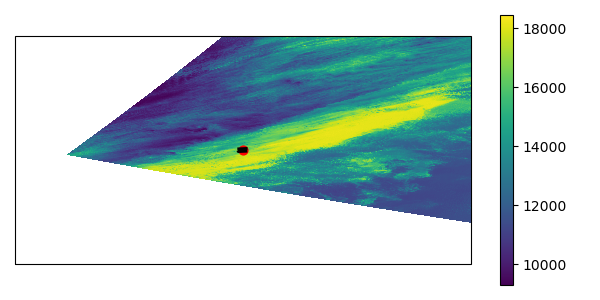

In [18]:
plt.figure(figsize=(6, 3))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.set_ylim([ilat-1,ilat+1])
ax.set_xlim([ilon-2,ilon+2])
cb = ax.pcolormesh(ls_scene.x,ls_scene.y,ls_scene.sel(band=1).to_array().isel(variable=0),transform=cartopy.crs.epsg(3031))
plt.scatter([ilon],[ilat],c='r',s=40,transform=ccrs.PlateCarree())
plt.plot([polarx[0],polarx[0],polarx[1],polarx[1],polarx[0]],[polary[0],polary[1],polary[1],polary[0],polary[0]],lw=2,ls='--',color='k',transform=cartopy.crs.epsg(3031))
ax.coastlines()
plt.colorbar(cb)
plt.tight_layout()

**Note the bands you would like to include are assigned by passing the bandNames parameter to landsat_to_xarray using the following codes:**

'coastal', 'blue', 'green', 'red', 'nir08', 'swir16', 'swir22', 'pan', 'cirrus', 'lwir11', 'lwir12', 'qa_pixel'

# Landsat-iQUAM validation assessment

In [34]:
# Read in processed matchups

out_df = lsatpath / 'Landsat_validation_20250919_202209_202303_1.0.csv'
df1 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_202109_202203_1.0.csv'
df2 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_202009_202103_1.0.csv'
df3 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_201909_202003_1.0.csv'
df4 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_201809_201903_1.0.csv'
df5 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_201709_201803_1.0.csv'
df6 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_201609_201703_1.0.csv'
df7 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_201509_201603_1.0.csv'
df8 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_201409_201503_1.0.csv'
df9 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_20250919_201309_201403_1.0.csv'
df10 = pd.read_csv(out_df, index_col=0)

valids = pd.concat([df1,df2,df3,df4,df5,df6,df7,df8,df9,df10]) 

valids = valids.set_index('DateTime')
valids = valids.sort_index()
valids['Argo_id'] = valids['Argo_id'].astype(int)

valids = valids.dropna(subset=['L8_SST'])

# Remove the non-numeric column for calculating daily means
numeric_valids = valids.select_dtypes(include=[np.number])
validmn = numeric_valids.groupby(numeric_valids['Argo_id']).mean()
valids = valids.reset_index()

# Group by the date component of the datetime and calculate the difference
valids['temp_dif'] = valids.groupby(valids['Argo_id'])[f'L8_SST'].diff()
validmn['temp_dif'] = valids.groupby(valids['Argo_id'])['temp_dif'].first()
valids = valids.set_index('DateTime')

validmn['std'] = valids.groupby([valids['Argo_id']])[f'L8_SST'].std()
validmn['xaxis'] = pd.to_datetime(validmn.index).dayofyear
validmn['xaxis'][validmn['xaxis']<(365/2)] = validmn['xaxis'] + 365
validmn = validmn[validmn.Depth<5.0] # remove matchups with argo data below 5 m

valids['xaxis'] = pd.to_datetime(valids.index).dayofyear
valids['xaxis'][valids['xaxis']<(365/2)] = valids['xaxis'] + 365

print(f"valids has {len(valids)} rows")
print(f"validmn has {len(validmn)} rows (grouped by argo_id)")

valids_argo = valids
validmn_argo = validmn

valids_argo

valids has 11 rows
validmn has 10 rows (grouped by argo_id)


,L8_filename,L8_SST,L8_std,center,N,S,E,W,NE,SE,...,L8_SST_max,L8_SST_min,Argo_id,Argo_SST,Depth,A_lat,A_lon,platform_type,temp_dif,xaxis
DateTime,,,,,,,,,,,,,,,,,,,,,
2015-12-11 10:00:00,LC08_L1GT_027110_20151211_20201016_02_T2,-1.06,0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.769147,-1.226289,1614080,-1.76,3.32,-70.38311,-135.92966,5.0,NaN,345
2016-02-13 08:00:00,LC08_L1GT_027111_20160213_20201016_02_T2,-1.73,0.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.565826,-1.886673,1460597,-0.53,4.54,-71.68700,-135.95200,5.0,NaN,409
2018-01-01 12:00:00,LC08_L1GT_228108_20180101_20201016_02_T2,-0.68,0.05,-0.650624,-0.601495,-0.684302,-0.640289,-0.640289,-0.573061,-0.692066,...,-0.469712,-0.837162,1790883,-0.05,4.59,-68.34400,-80.62500,5.0,NaN,366
2018-01-21 23:00:00,LC08_L1GT_023110_20180121_20201016_02_T2,-0.93,0.05,-0.952590,-0.931842,-0.955183,-0.978524,-0.929249,-0.957777,-0.962963,...,-0.806581,-1.121442,1799801,-1.08,3.17,-70.25800,-128.79600,5.0,NaN,386
2019-02-23 15:00:00,LC08_L1GT_226108_20190223_20201016_02_T2,0.95,0.09,0.927724,0.937753,0.935233,0.935233,0.915176,0.940273,0.947807,...,1.188241,0.550417,1711312,1.29,1.16,-67.72530,-76.59550,5.0,NaN,419
2020-03-10 02:00:00,LC08_L1GT_029110_20200309_20201016_02_T2,-0.93,0.05,-0.976236,-0.953593,-0.983793,-0.968680,-0.981257,-0.943526,-0.983792,...,-0.775327,-1.124736,2150128,-0.90,3.50,-70.24400,-137.68100,5.0,NaN,435
2020-03-30 02:00:00,LC08_L1GT_009109_20200329_20200822_02_T2,-1.12,0.17,-1.062827,-1.082924,-1.047784,-1.067857,-1.045257,-1.090458,-1.040226,...,-0.924893,-1.898526,2143782,-0.61,1.12,-69.02310,-104.13300,5.0,NaN,455
2021-03-31 03:00:00,LC08_L1GT_002109_20210331_20210408_02_T2,-1.13,0.06,-1.066079,-1.015775,-1.066079,-1.061061,-1.078674,-1.076140,-1.068589,...,-0.952926,-1.315657,1892417,-1.23,0.92,-69.08860,-92.05940,NaN,NaN,455
2021-03-31 03:00:00,LC08_L1GT_002108_20210331_20210408_02_T2,-1.13,0.06,-1.066079,-1.015775,-1.066079,-1.061061,-1.078674,-1.076140,-1.068589,...,-0.952926,-1.315657,1892417,-1.23,0.92,-69.08860,-92.05940,NaN,0.0,455


In [19]:
out_df = lsatpath / 'Landsat_sealBASSTR_validation_20260101_alltime_1.0.csv'
df1 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_sealIMOS_validation_20260101_alltime_1.0.csv'
df2 = pd.read_csv(out_df, index_col=0)
valids = pd.concat([df1, df2])

# Keep only rows where at least one of L8_SST or L8_SST_ani is NOT NaN, and seal_SST is real
valids = valids.dropna(subset=['L8_SST', 'L8_SST_ani'], how='all')
valids = valids.dropna(subset=['seal_SST'])
valids['loc_err[km]'] = valids['loc_err']/1000

# Only need to do temporarily until fix files
valids['seal_id'] = valids['platform_type'].astype(str) + '-' + valids['DateTime'].astype(str)

valids = valids.set_index('DateTime')
valids.index = pd.to_datetime(valids.index)  # Ensure index is datetime
valids = valids.sort_index()

# Remove the non-numeric column for calculating daily means
numeric_valids = valids.select_dtypes(include=[np.number])

valids = valids.dropna(subset=['seal_SST'], how='any') 

valids_sealargo = valids.dropna(subset=['L8_SST'], how='any') 
valids_sealani = valids.dropna(subset=['L8_SST_ani'], how='any')

# Group by seal_id only
validmn_sealargo = valids_sealargo.groupby('seal_id')[numeric_valids.columns].mean()
validmn_sealani = valids_sealani.groupby('seal_id')[numeric_valids.columns].mean()

valids_sealargo = valids_sealargo.reset_index()
validmn_sealargo = validmn_sealargo.reset_index()

valids_sealani = valids_sealani.reset_index()
validmn_sealani = validmn_sealani.reset_index()

# Group by seal_id and calculate the difference
valids_sealargo['temp_dif'] = valids_sealargo.groupby('seal_id')['L8_SST'].diff()
validmn_sealargo['temp_dif'] = valids_sealargo.groupby('seal_id')['temp_dif'].first()

valids_sealani['temp_dif'] = valids_sealani.groupby('seal_id')['L8_SST_ani'].diff()
validmn_sealani['temp_dif'] = valids_sealani.groupby('seal_id')['temp_dif'].first()

valids_sealargo = valids_sealargo.set_index('DateTime')
valids_sealargo.index = pd.to_datetime(valids_sealargo.index)  # Ensure index is datetime

valids_sealani = valids_sealani.set_index('DateTime')
valids_sealani.index = pd.to_datetime(valids_sealani.index)  # Ensure index is datetime

# Calculate std for validmn
validmn_sealargo['std'] = valids_sealargo.groupby('seal_id')['L8_SST'].std().values
validmn_sealani['std_ani'] = valids_sealani.groupby('seal_id')['L8_SST_ani'].std().values

# For validmn, get the first DateTime for each seal_id
validmn_sealargo['DateTime'] = valids_sealargo.reset_index().groupby('seal_id')['DateTime'].first().values
validmn_sealargo['xaxis'] = pd.to_datetime(validmn_sealargo['DateTime']).dt.dayofyear
validmn_sealargo['xaxis'] = validmn_sealargo['xaxis'].where(validmn_sealargo['xaxis'] >= (365/2), validmn_sealargo['xaxis'] + 365)

validmn_sealani['DateTime'] = valids_sealani.reset_index().groupby('seal_id')['DateTime'].first().values
validmn_sealani['xaxis'] = pd.to_datetime(validmn_sealani['DateTime']).dt.dayofyear
validmn_sealani['xaxis'] = validmn_sealani['xaxis'].where(validmn_sealani['xaxis'] >= (365/2), validmn_sealani['xaxis'] + 365)

# For valids, use the index
valids_sealargo['xaxis'] = valids_sealargo.index.dayofyear
valids_sealargo['xaxis'] = valids_sealargo['xaxis'].where(valids_sealargo['xaxis'] >= (365/2), valids_sealargo['xaxis'] + 365)

valids_sealani['xaxis'] = valids_sealani.index.dayofyear
valids_sealani['xaxis'] = valids_sealani['xaxis'].where(valids_sealani['xaxis'] >= (365/2), valids_sealani['xaxis'] + 365)

print(f"Argo seal valids has {len(valids_sealargo)} rows")
print(f"Argo seal validmn has {len(validmn_sealargo)} rows (grouped by seal_id)")

print(f"Animotum valids has {len(valids_sealani)} rows")
print(f"Animotum validmn has {len(validmn_sealani)} rows (grouped by seal_id)")

valids_sealargo.tail()

Argo seal valids has 42 rows
Argo seal validmn has 39 rows (grouped by seal_id)
Animotum valids has 49 rows
Animotum validmn has 41 rows (grouped by seal_id)


,L8_filename,L8_SST,L8_std,center,L8_SST_max,L8_SST_min,L8_SST_ani,L8_std_ani,center_ani,seal_id,...,A_lat,A_lon,A_lat_ani,A_lon_ani,loc_err,qc[x_y_xse_yse],time_dif,loc_err[km],temp_dif,xaxis
DateTime,,,,,,,,,,,,,,,,,,,,,
2022-03-15 11:49:59,LC08_L1GT_013112_20220315_20220321_02_T2,-1.87,0.02,NaN,-1.814071,-1.897794,-1.88,0.02,NaN,ct167-Manoela-21-2022-03-15 11:49:59,...,-73.2274,-116.1329,-73.232152,-116.105525,1468.058164,qc_ssm_x -12924807.958565\nqc_ssm_y ...,0 days 04:15:32.978135,1.468058,NaN,439
2022-03-16 01:10:00,LC08_L1GT_013112_20220315_20220321_02_T2,-1.87,0.02,NaN,-1.805675,-1.899561,NaN,NaN,NaN,ct167-Manoela-21-2022-03-16 01:10:00,...,-73.3125,-116.4528,-73.256599,-116.627898,4125.783881,qc_ssm_x -12982958.240644\nqc_ssm_y ...,0 days 09:04:28.021865,4.125784,NaN,440
2023-10-05 15:19:59,LC08_L1GT_060107_20231005_20231011_02_T2,-1.73,0.10,NaN,-1.463245,-1.899442,NaN,NaN,NaN,ft33-789-22-2023-10-05 15:19:59,...,-67.3347,-179.9143,-67.369000,179.980900,10286.902071,qc_ssm_x 2340.2099\nqc_ssm_y -850....,0 days 05:34:12.481208,10.286902,NaN,278
2023-10-05 16:19:59,LC08_L1GT_060107_20231005_20231011_02_T2,-1.83,0.05,NaN,-1.721758,-1.899442,NaN,NaN,NaN,ft33-789-22-2023-10-05 16:19:59,...,-67.3233,-179.9511,-67.362700,-179.999200,15786.322530,qc_ssm_x 2340.5791\nqc_ssm_y -851....,0 days 04:34:12.481208,15.786323,NaN,278
2023-10-06 02:09:59,LC08_L1GT_060107_20231005_20231011_02_T2,-1.87,0.03,NaN,-1.776935,-1.899442,-1.85,0.04,NaN,ft33-789-22-2023-10-06 02:09:59,...,-67.3160,-179.6250,-67.294100,-179.651100,10610.045310,qc_ssm_x 2342.6218\nqc_ssm_y -868....,0 days 05:15:47.518792,10.610045,NaN,279


(array([6., 7., 3., 4., 7., 4., 2., 2., 0., 1., 0., 1., 1., 1., 2., 0., 2.,
        0., 3., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 2.]),
 array([  895.68993552,  1650.93309626,  2406.176257  ,  3161.41941775,
         3916.66257849,  4671.90573924,  5427.14889998,  6182.39206072,
         6937.63522147,  7692.87838221,  8448.12154295,  9203.3647037 ,
         9958.60786444, 10713.85102519, 11469.09418593, 12224.33734667,
        12979.58050742, 13734.82366816, 14490.06682891, 15245.30998965,
        16000.55315039, 16755.79631114, 17511.03947188, 18266.28263263,
        19021.52579337, 19776.76895411, 20532.01211486, 21287.2552756 ,
        22042.49843635, 22797.74159709, 23552.98475783]),
 <BarContainer object of 30 artists>)

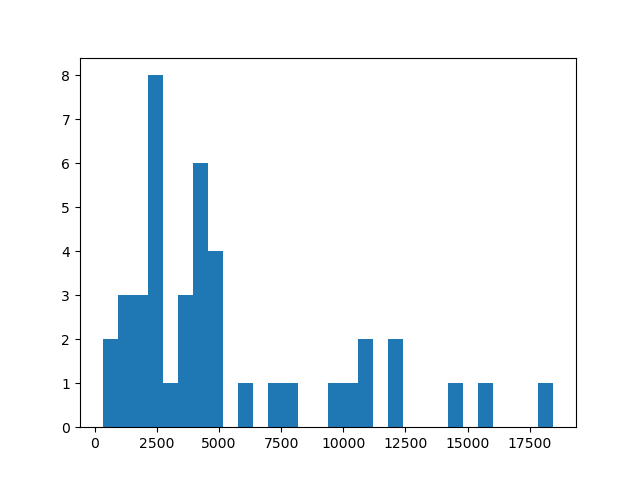

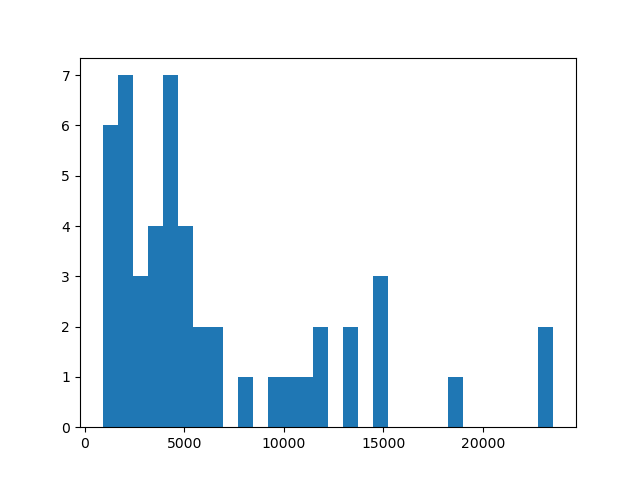

In [20]:
# print (valids_seal.loc_err.min(), valids_seal.loc_err.max())
plt.figure()
plt.hist(valids_sealargo.loc_err, bins=30)

plt.figure()
plt.hist(valids_sealani.loc_err, bins=30)

## Visualize all validation matchups for manual QC

### Argo buoys

In [21]:
os.chdir(iqvalid_path)
lsatfiles = os.listdir(iqvalid_path)
lsatfiles = [i for i in lsatfiles if i[0]=='L']

# Remove all files from the list with repeats and Landsat mean = nan
remove = [
'LC08_L1GT_029109_20160922_20200906_02_T2', 
'LC08_L1GT_022110_20181029_20201016_02_T2', 
'LC08_L1GT_005110_20181209_20201016_02_T2',
'LC08_L1GT_228108_20200123_20201016_02_T2',
'LC08_L1GT_001108_20200929_20201006_02_T2',
'LC08_L1GT_002109_20201022_20201105_02_T2',
'LC08_L1GT_233108_20201109_20210317_02_T2',
'LC08_L1GT_233109_20201109_20210317_02_T2',
'LC08_L1GT_001109_20201202_20210312_02_T2',
'LC08_L1GT_027112_20220128_20220204_02_T2',
'LC08_L1GT_002109_20210331_20210408_02_T2'
]

lsatfiles = [i for i in lsatfiles if i[:-15] not in remove]
if len(lsatfiles)!=12:
    print('Wrong number of Landsat scenes!!!')

In [ ]:
# Number of columns/rows for subplots
n_cols = 3
n_rows = 4

# Create figure
fig = plt.figure(figsize=(11, 8.5))

# Create GridSpec
gs = GridSpec(n_rows, n_cols, figure=fig, wspace=0.05, hspace=0.03)

# Create axes list
axes = []
for row in range(n_rows):
    for col in range(n_cols):
        # For the last row, only create the middle subplot
        if row == n_rows - 1 and col != 1:
            continue
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        axes.append(ax)

# Counter for subplot index, and a handle to store the last "imshow" (for colorbar)
i = 0
im_obj = None

for lsatfile in lsatfiles:
    lsID = lsatfile
    print(lsID)
    
    mrow = valids_argo[valids_argo['L8_filename'].str.contains(lsatfile[:-15])]
    
    for idx, row in mrow.iterrows():
        # # Check if L8_SST is NaN
        # if pd.isnull(row['L8_SST']):
        #     # If it is NaN, skip this iteration and do not plot
        #     print (f'Skipping {row['Argo_id']}')
        #     continue
        
        # --- Prepare data and coordinates ---
        ilat = row['A_lat']
        ilon = row['A_lon']
        
        lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
        lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
        xmin, ymin, xmax, ymax = (ilon - lon_add, ilat - lat_add, 
                                  ilon + lon_add, ilat + lat_add)
        
        # Load the Landsat file
        ds = xr.open_dataset(iqvalid_path / lsatfile, chunks=dict(x=512, y=512), engine='rasterio')
        ls_scene = ds['band_data'].sel(band=1).rio.write_crs("epsg:3031", inplace=True)
        
        # Assign time coordinate
        times = pd.to_datetime(lsatfile[17:25] + lsatfile[41:47], format='%Y%m%d%H%M%S')
        ls_scene = ls_scene.assign_coords(time=times, ID=lsatfile[:-8])
        
        # Reproject to EPSG:4326
        ls_scene = ls_scene.rio.reproject("EPSG:4326")

        # Calibrate using MODIS
        ls_scene = ls_scene * calib_m + calib_b

        # Remove all pixels that are too cold
        ls_scene = ls_scene.where(ls_scene>=lthresh, np.nan)
        
        # Select the subplot axis
        ax = axes[i]
        
        # Plot on that axis, without a colorbar
        im_obj = ls_scene.plot.imshow(
            x='x', y='y',
            vmin=-2.0, vmax=1.5,
            ax=ax,
            transform=ccrs.PlateCarree(),
            origin='upper',
            add_colorbar=False
        )
        
        # Remove titles completely
        ax.set_title('')
        
        # Set extent
        ax.set_extent([ilon - 0.4, ilon + 0.4, ilat - 0.2, ilat + 0.2], crs=ccrs.PlateCarree())
        
        # Argo observation
        ax.scatter([ilon], [ilat], c='r', s=3, transform=ccrs.PlateCarree(), label='Argo location')
        
        # Draw bounding box
        polygon_show = Pgon([(xmin, ymin), (xmin, ymax), 
                             (xmax, ymax), (xmax, ymin)],
                            closed=True, edgecolor='red', facecolor='none')
        ax.add_patch(polygon_show)
        
        # Text label
        text_str = (
            f"Argo ID: {row['Argo_id']}\n"
            f"Argo Temp: {np.around(row['Argo_SST'], 2)}\n"
            f"Landsat SST: {np.around(row['L8_SST'], 2)}"
        )
        ax.text(
            0.02, 0.95,
            text_str,
            transform=ax.transAxes,
            fontsize=10,
            va='top',
            ha='left'
        )

        gc.collect()
        
        # Move to next subplot index
        i += 1

# --- Add a single colorbar for the entire figure ---
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.03])

cbar = fig.colorbar(
    im_obj, 
    ax=axes,
    cax=cbar_ax,
    orientation='horizontal',
    fraction=0.025,
    pad=0.05
)
cbar.set_label("Temperature [°C]", fontsize=12)

plt.savefig('validationMatchups.pdf', 
            bbox_inches='tight',
            dpi=400,
            format='pdf')  
plt.show()

### Seal tags

In [22]:
os.chdir(svalid_path)
lsatfiles = os.listdir(svalid_path)
lsatfiles = [i for i in lsatfiles if i[0]=='L']

# Remove all seal dives from the list with repeats, nans and Landsat mean = nan
df_sealargo = valids_sealargo

# Get boolean mask of duplicate entries
duplicate_mask = df_sealargo['seal_id'].duplicated(keep='first')  # marks duplicates (keeps first occurrence)

# See the actual duplicate index values
df_sealargo = df_sealargo[~duplicate_mask]
print (f'{duplicate_mask.sum()} duplicates removed, {df_sealargo.shape[0]} remain')

# lsatfiles = [i for i in lsatfiles if i[:-15] not in remove]
# if len(lsatfiles)!=12:
#     print('Wrong number of Landsat scenes!!!')

3 duplicates removed, 39 remain


LC08_L1GT_001113_20200305_20200822_02_T2_145146_Cel.tif
LC08_L1GT_008111_20200322_20200822_02_T2_153405_Cel.tif
LC08_L1GT_004111_20200310_20200822_02_T2_150928_Cel.tif
LC08_L1GT_003112_20190213_20201016_02_T2_150332_Cel.tif
LC08_L1GT_003112_20200319_20200822_02_T2_150337_Cel.tif
LC08_L1GT_001113_20190215_20201016_02_T2_145134_Cel.tif
LC08_L1GT_232113_20200323_20200822_02_T2_143915_Cel.tif
LC08_L1GT_004112_20190220_20201016_02_T2_150942_Cel.tif
LC08_L1GT_006111_20200324_20200822_02_T2_152142_Cel.tif
LC08_L1GT_001113_20190303_20200829_02_T2_145130_Cel.tif
LC08_L1GT_006110_20200324_20200822_02_T2_152118_Cel.tif
LC08_L1GT_005112_20190315_20200829_02_T2_151545_Cel.tif
LC08_L1GT_002112_20200328_20200822_02_T2_145721_Cel.tif
LC08_L1GT_003113_20190317_20200829_02_T2_150347_Cel.tif
LC08_L1GT_009112_20220215_20220223_02_T2_154057_Cel.tif
LC08_L1GT_003112_20190317_20200829_02_T2_150323_Cel.tif
LC08_L1GT_010112_20220310_20220321_02_T2_154702_Cel.tif
LC08_L1GT_004112_20190324_20200829_02_T2_150933_

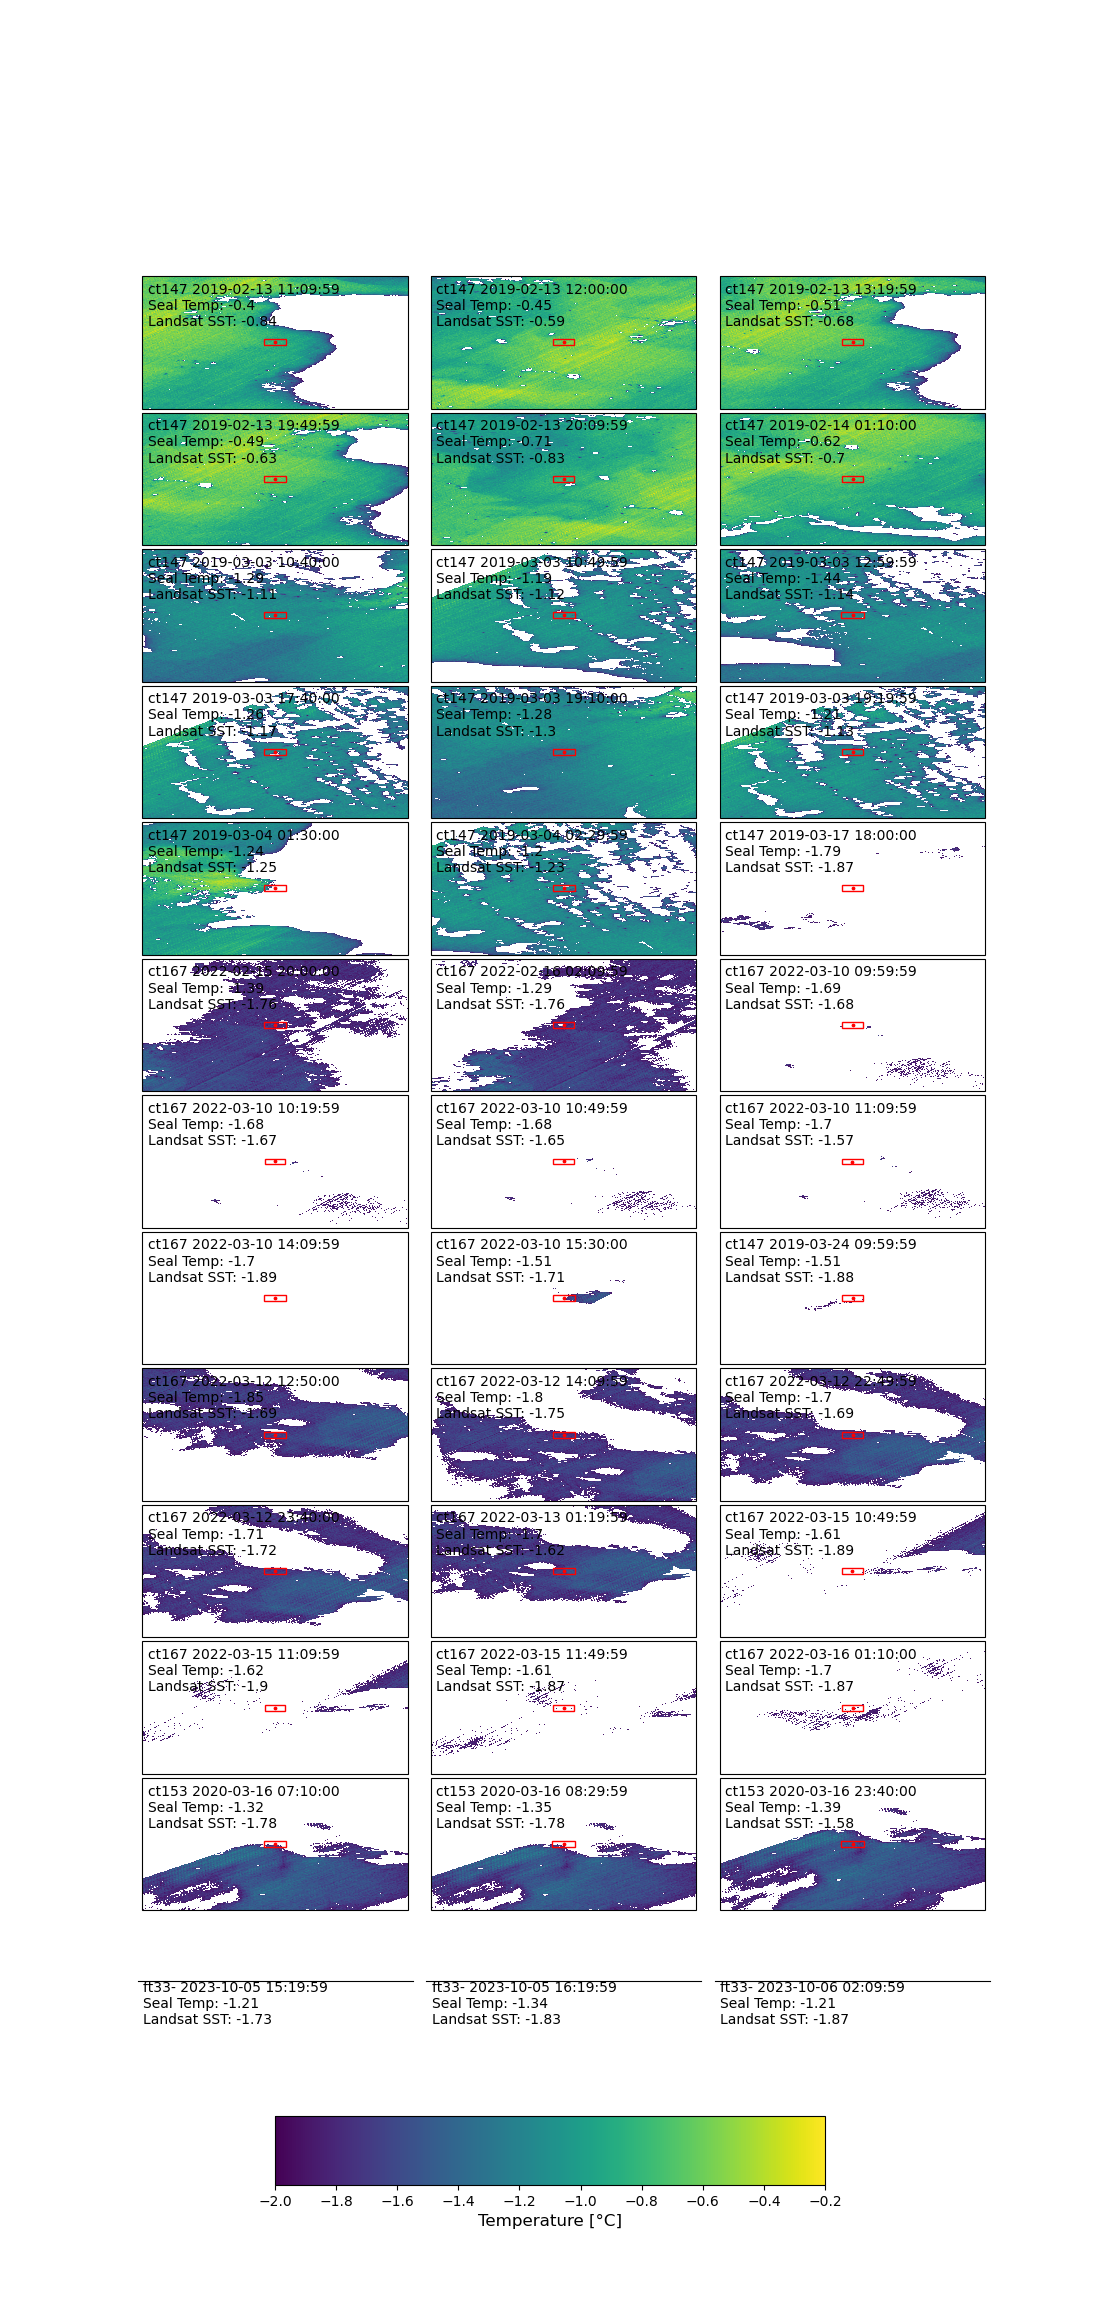

In [23]:
# 8 duplicates with same seal tag dive + slightly different SST image.
#***fix landsat image production for the international dateline images.

# Number of columns/rows for subplots
n_cols = 3
n_rows = 13

# Create one figure and a 4x7 grid of subplots
# The figsize is 10 across; adjust height as needed for clarity
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(11, 23),   
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Optional: if you want them *really* close, you can fine-tune spacing:
plt.subplots_adjust(wspace=0.05, hspace=0.03)
# plt.subplots_adjust(bottom=0.15)

# Counter for subplot index, and a handle to store the last "imshow" (for colorbar)
i = 0
im_obj = None

for lsatfile in lsatfiles:
    lsID = lsatfile
    print(lsID)
    
    mrow = df_sealargo[df_sealargo['L8_filename'].str.contains(lsatfile[:-15])]
    
    for idx, row in mrow.iterrows():     
        # Prepare data and coordinates
        ilat = row['A_lat']
        ilon = row['A_lon']
        
        lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
        lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
        xmin, ymin, xmax, ymax = (ilon - lon_add, ilat - lat_add, 
                                  ilon + lon_add, ilat + lat_add)
        
        # Load the Landsat file
        ds = xr.open_dataset(svalid_path / lsatfile, chunks=dict(x=512, y=512))
        ls_scene = ds['band_data'].sel(band=1).rio.write_crs("epsg:3031", inplace=True)
        
        # Assign time coordinate
        times = pd.to_datetime(lsatfile[17:25] + lsatfile[41:47], format='%Y%m%d%H%M%S')
        ls_scene = ls_scene.assign_coords(time=times, ID=lsatfile[:-8])
        
        # Reproject to EPSG:4326
        ls_scene = ls_scene.rio.reproject("EPSG:4326")

        # Cross-calibrate
        ls_scene = ls_scene * calib_m + calib_b

        # Remove all pixels that are too cold
        ls_scene = ls_scene.where(ls_scene>=lthresh,np.nan)
        
        # Select the subplot axis
        ax = axes[i // n_cols, i % n_cols]
        
        # Plot on that axis, without a colorbar
        # Store the "imshow" result in im_obj so we can build one colorbar later
        im_obj = ls_scene.plot.imshow(
            x='x', y='y',
            vmin=-2.0, vmax=-0.2,
            ax=ax,
            transform=ccrs.PlateCarree(),
            origin='upper',
            add_colorbar=False  # <- No individual colorbar
        )
        
        # Remove titles completely (xarray may add one by default)
        ax.set_title('')
        
        # Set extent
        ax.set_extent([ilon - 0.4, ilon + 0.4, ilat - 0.2, ilat + 0.2], crs=ccrs.PlateCarree())
        
        # Argo observation
        ax.scatter([ilon], [ilat], c='r', s=3, transform=ccrs.PlateCarree(), label='Seal location')
        
        # Draw bounding box
        polygon_show = Pgon([(xmin, ymin), (xmin, ymax), 
                             (xmax, ymax), (xmax, ymin)],
                            closed=True, edgecolor='red', facecolor='none')
        ax.add_patch(polygon_show)
        
        # Text label
        text_str = (
            f"{row['seal_id'][:5]} {row['seal_id'][-19:]}\n"
            f"Seal Temp: {np.around(row['seal_SST'], 2)}\n"
            f"Landsat SST: {np.around(row['L8_SST'], 2)}"
        )
        ax.text(
            0.02, 0.95,
            text_str,
            transform=ax.transAxes,
            fontsize=10,
            va='top',
            ha='left'
        )

        gc.collect()
        
        # Move to next subplot index
        i += 1
        

# --- Add a single colorbar for the entire figure ---
# We use the last "imshow" (im_obj) and attach to all subplot axes
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.03])

cbar = fig.colorbar(
    im_obj, 
    ax=axes.ravel().tolist(),  # or just ax=axes if axes is 2D
    cax=cbar_ax,
    orientation='horizontal',  # 'vertical' or 'horizontal'
    fraction=0.025,            # how long the colorbar is relative to axes
    pad=0.05                   # space between colorbar and subplots
)
cbar.set_label("Temperature [°C]", fontsize=12)

plt.savefig('validationSealMatchups.pdf', 
            bbox_inches='tight',  # Removes extra whitespace
            dpi=400,              # Higher resolution
            format='pdf')  
plt.show() 

In [24]:
# Choosing index from pictures above starting count at 0
rm_idx_argo = [14,17,18,19,20,21,23,29,30,31,32,33,34,36,37,38]

In [25]:
os.chdir(svalid_path)
lsatfiles = os.listdir(svalid_path)
lsatfiles = [i for i in lsatfiles if i[0]=='L']

# Remove all seal dives from the list with repeats, nans and Landsat mean = nan
df_sealani = valids_sealani

# Get boolean mask of duplicate entries
duplicate_mask = df_sealani['seal_id'].duplicated(keep='first')  # marks duplicates (keeps first occurrence)

# See the actual duplicate index values
df_sealani = df_sealani[~duplicate_mask]
print (f'{duplicate_mask.sum()} duplicates removed, {df_sealani.shape[0]} remain')

8 duplicates removed, 41 remain


LC08_L1GT_001113_20200305_20200822_02_T2_145146_Cel.tif
LC08_L1GT_008111_20200322_20200822_02_T2_153405_Cel.tif
LC08_L1GT_004111_20200310_20200822_02_T2_150928_Cel.tif
LC08_L1GT_003112_20190213_20201016_02_T2_150332_Cel.tif
LC08_L1GT_003112_20200319_20200822_02_T2_150337_Cel.tif
LC08_L1GT_001113_20190215_20201016_02_T2_145134_Cel.tif
LC08_L1GT_232113_20200323_20200822_02_T2_143915_Cel.tif
LC08_L1GT_004112_20190220_20201016_02_T2_150942_Cel.tif
LC08_L1GT_006111_20200324_20200822_02_T2_152142_Cel.tif
LC08_L1GT_001113_20190303_20200829_02_T2_145130_Cel.tif
LC08_L1GT_006110_20200324_20200822_02_T2_152118_Cel.tif
LC08_L1GT_005112_20190315_20200829_02_T2_151545_Cel.tif
LC08_L1GT_002112_20200328_20200822_02_T2_145721_Cel.tif
LC08_L1GT_003113_20190317_20200829_02_T2_150347_Cel.tif
LC08_L1GT_009112_20220215_20220223_02_T2_154057_Cel.tif
LC08_L1GT_003112_20190317_20200829_02_T2_150323_Cel.tif
LC08_L1GT_010112_20220310_20220321_02_T2_154702_Cel.tif
LC08_L1GT_004112_20190324_20200829_02_T2_150933_

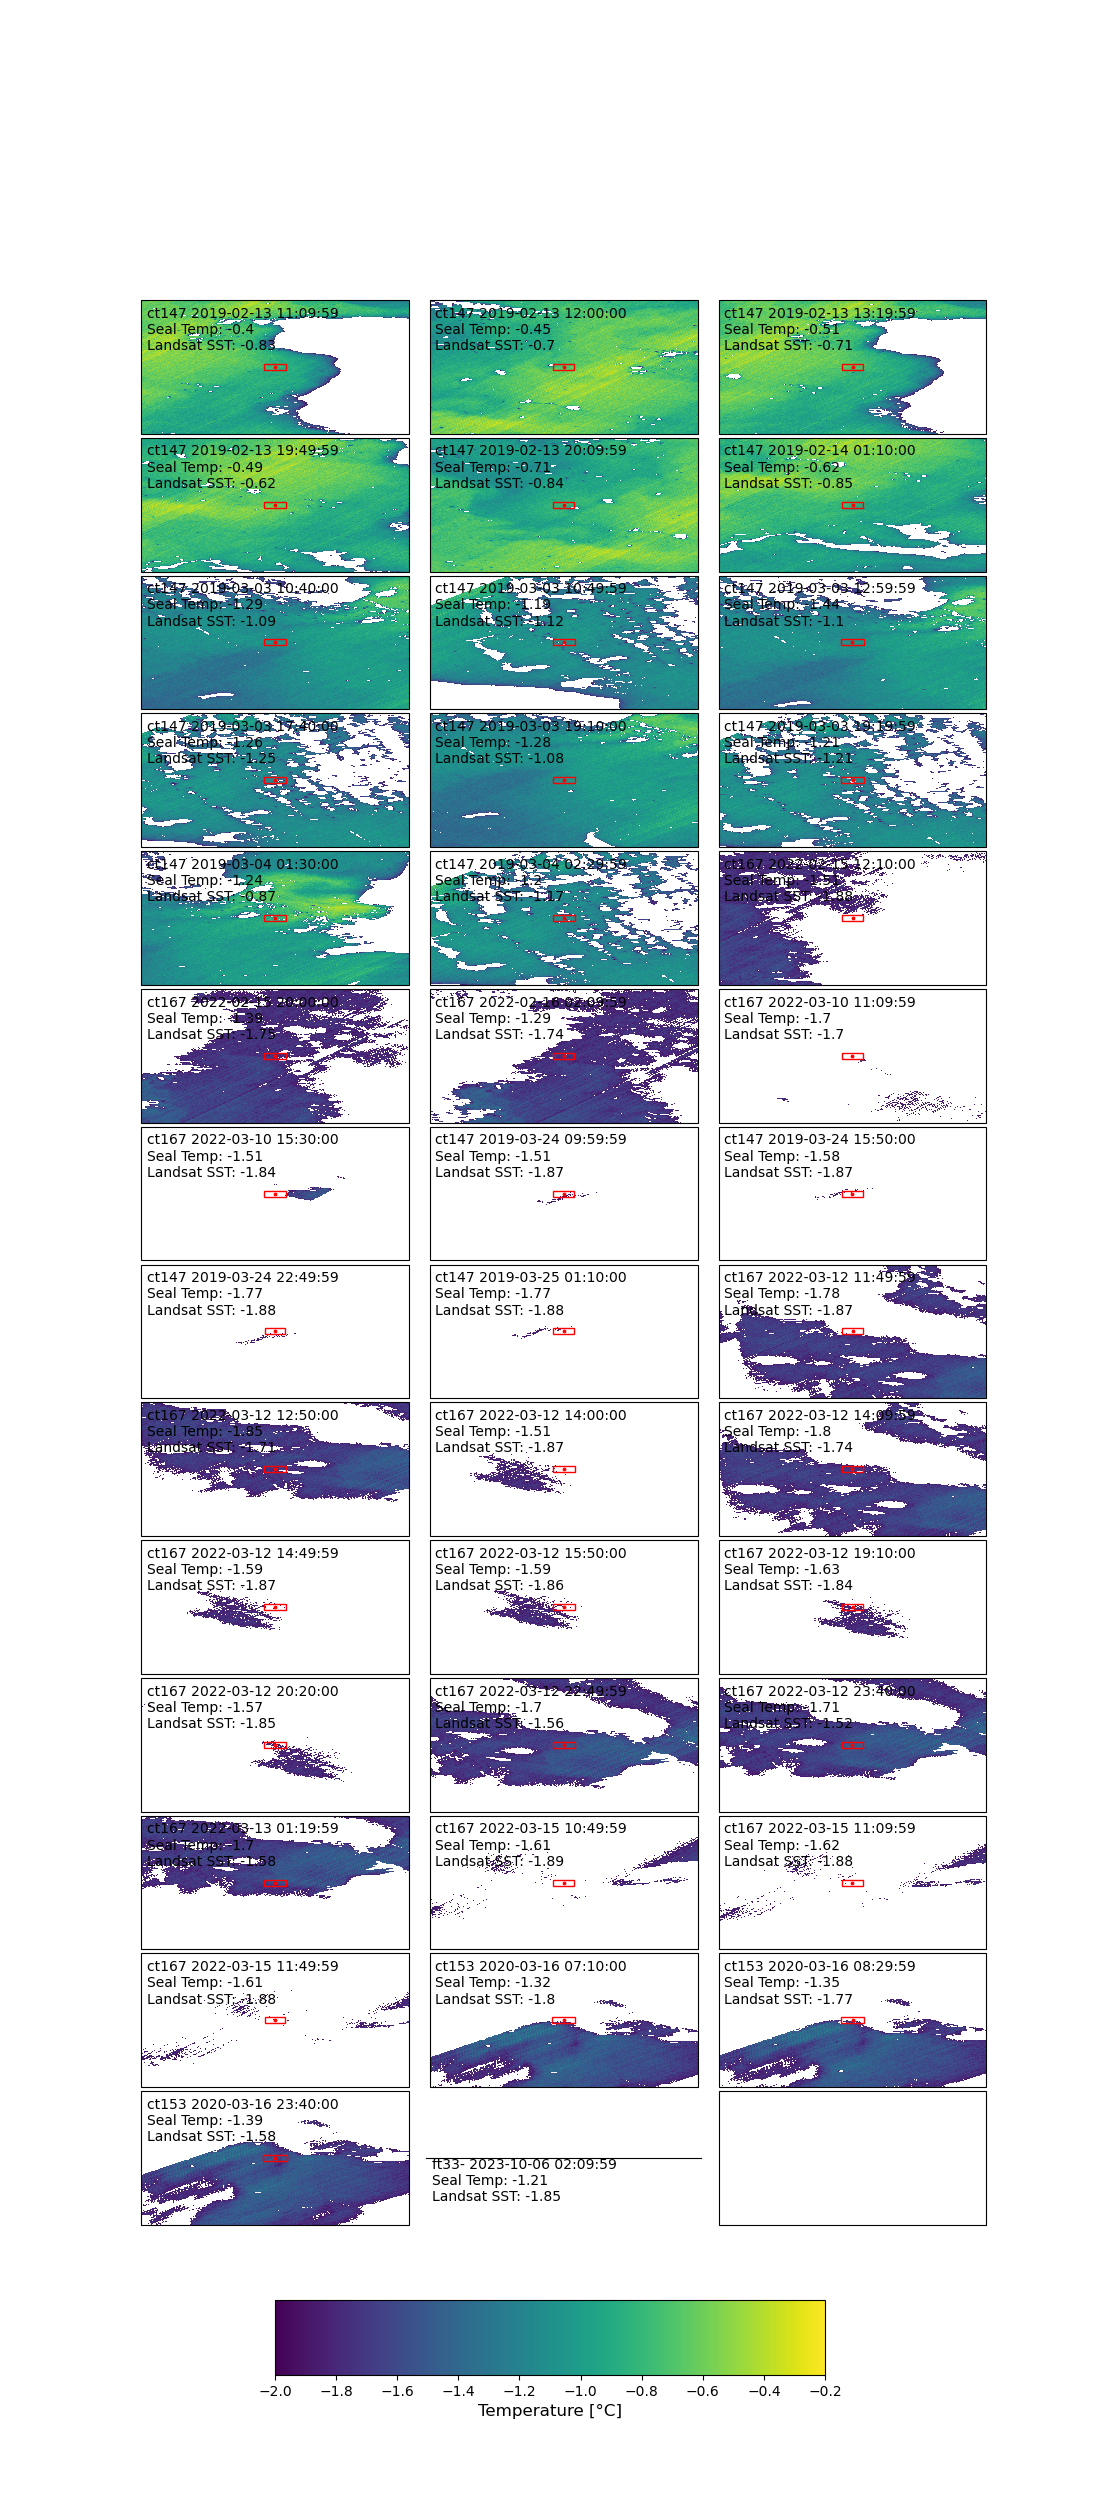

In [13]:
# 8 duplicates with same seal tag dive + slightly different SST image.
#***fix landsat image production for the international dateline images.

# Number of columns/rows for subplots
n_cols = 3
n_rows = 14

# Create one figure and a 4x7 grid of subplots
# The figsize is 10 across; adjust height as needed for clarity
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(11, 25),   
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Optional: if you want them *really* close, you can fine-tune spacing:
plt.subplots_adjust(wspace=0.05, hspace=0.03)
# plt.subplots_adjust(bottom=0.15)

# Counter for subplot index, and a handle to store the last "imshow" (for colorbar)
i = 0
im_obj = None

for lsatfile in lsatfiles:
    lsID = lsatfile
    print(lsID)
    
    mrow = df_sealani[df_sealani['L8_filename'].str.contains(lsatfile[:-15])]
    
    for idx, row in mrow.iterrows():
        # Check if L8_SST is NaN
        if pd.isnull(row['L8_SST_ani']) | pd.isnull(row['seal_SST']):
            # If it is NaN, skip this iteration and do not plot
            continue
        
        # Prepare data and coordinates
        ilat = row['A_lat_ani']
        ilon = row['A_lon_ani']
        
        lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
        lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
        xmin, ymin, xmax, ymax = (ilon - lon_add, ilat - lat_add, 
                                  ilon + lon_add, ilat + lat_add)
        
        # Load the Landsat file
        ds = xr.open_dataset(svalid_path / lsatfile, chunks=dict(x=512, y=512))
        ls_scene = ds['band_data'].sel(band=1).rio.write_crs("epsg:3031", inplace=True)
        
        # Assign time coordinate
        times = pd.to_datetime(lsatfile[17:25] + lsatfile[41:47], format='%Y%m%d%H%M%S')
        ls_scene = ls_scene.assign_coords(time=times, ID=lsatfile[:-8])
        
        # Reproject to EPSG:4326
        ls_scene = ls_scene.rio.reproject("EPSG:4326")

        # Cross-calibrate
        ls_scene = ls_scene * calib_m + calib_b

        # Remove all pixels that are too cold
        ls_scene = ls_scene.where(ls_scene>=lthresh,np.nan)
        
        # Select the subplot axis
        ax = axes[i // n_cols, i % n_cols]
        
        # Plot on that axis, without a colorbar
        # Store the "imshow" result in im_obj so we can build one colorbar later
        im_obj = ls_scene.plot.imshow(
            x='x', y='y',
            vmin=-2.0, vmax=-0.2,
            ax=ax,
            transform=ccrs.PlateCarree(),
            origin='upper',
            add_colorbar=False  # <- No individual colorbar
        )
        
        # Remove titles completely (xarray may add one by default)
        ax.set_title('')
        
        # Set extent
        ax.set_extent([ilon - 0.4, ilon + 0.4, ilat - 0.2, ilat + 0.2], crs=ccrs.PlateCarree())
        
        # Argo observation
        ax.scatter([ilon], [ilat], c='r', s=3, transform=ccrs.PlateCarree(), label='Seal location')
        
        # Draw bounding box
        polygon_show = Pgon([(xmin, ymin), (xmin, ymax), 
                             (xmax, ymax), (xmax, ymin)],
                            closed=True, edgecolor='red', facecolor='none')
        ax.add_patch(polygon_show)
        
        # Text label
        text_str = (
            f"{row['seal_id'][:5]} {row['seal_id'][-19:]}\n"
            f"Seal Temp: {np.around(row['seal_SST'], 2)}\n"
            f"Landsat SST: {np.around(row['L8_SST_ani'], 2)}"
        )
        ax.text(
            0.02, 0.95,
            text_str,
            transform=ax.transAxes,
            fontsize=10,
            va='top',
            ha='left'
        )

        gc.collect()
        
        # Move to next subplot index
        i += 1
        

# --- Add a single colorbar for the entire figure ---
# We use the last "imshow" (im_obj) and attach to all subplot axes
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.03])

cbar = fig.colorbar(
    im_obj, 
    ax=axes.ravel().tolist(),  # or just ax=axes if axes is 2D
    cax=cbar_ax,
    orientation='horizontal',  # 'vertical' or 'horizontal'
    fraction=0.025,            # how long the colorbar is relative to axes
    pad=0.05                   # space between colorbar and subplots
)
cbar.set_label("Temperature [°C]", fontsize=12)

plt.savefig('validationSealMatchups_animotum.pdf', 
            bbox_inches='tight',  # Removes extra whitespace
            dpi=400,              # Higher resolution
            format='pdf')  
plt.show() 

In [26]:
# Choosing index from pictures above starting count at 0
rm_idx_ani = [14,17,18,19,20,21,22,23,25,27,28,29,30,34,35,36,37,38,40] 

## Plot high and low quality validation data

### Argo

In [27]:
# Remove low quality validation data from the valids data
rm_ids = [1460597, 1614080, 2143782, 2016236, 1790883] 
rm = validmn_argo[validmn_argo.index.isin(rm_ids)]
validmn_argo_clean = validmn_argo.drop(index=rm_ids, errors='ignore')
valids_argo_clean = valids_argo[~valids_argo['Argo_id'].isin(rm_ids)]

In [28]:
# Orthoganal Regression 
data = validmn_argo_clean

# Original data
x_original = np.array(data['Argo_SST'])
y_original = np.array(data['L8_SST'])

# Define a linear function for the model
def linear_model(p, x):
    return p[0] * x + p[1]

# Create a Model
linear = Model(linear_model)

# Create a RealData object using your DataFrame
mdata = RealData(x_original, y_original)

# Set up ODR with the model and data
odr = ODR(mdata, linear, beta0=[1., 0.])

# Run the regression
out = odr.run()

# Use the output
beta = out.beta
beta_err = out.sd_beta

# Print the summary
out.pprint()

# Predicting values using the ODR model
y_pred = linear_model(beta, x_original)

# Get R2
# Calculate Total Sum of Squares (SST)
y_mean = np.mean(y_original)
SST = np.sum((y_original - y_mean)**2)

# Calculate Residual Sum of Squares (SSR)
SSR = np.sum((y_original - y_pred)**2)

# Compute RMSE
rmse = np.sqrt(((y_original - y_pred) ** 2).mean())

# Calculate R^2
R2 = 1 - (SSR / SST)
print("R^2:", np.around(R2,2))
print(f"RMSE: {np.around(rmse,2)}")

Beta: [ 0.84278945 -0.04030151]
Beta Std Error: [0.06444192 0.07048475]
Beta Covariance: [[0.33373679 0.19523594]
 [0.19523594 0.3992616 ]]
Residual Variance: 0.012443221865766454
Inverse Condition #: 0.0786472233640533
Reason(s) for Halting:
  Sum of squares convergence
R^2: 0.98
RMSE: 0.12


At 95% confidence interval: 0.84+/-0.13, -0.04+/-0.14, n=6


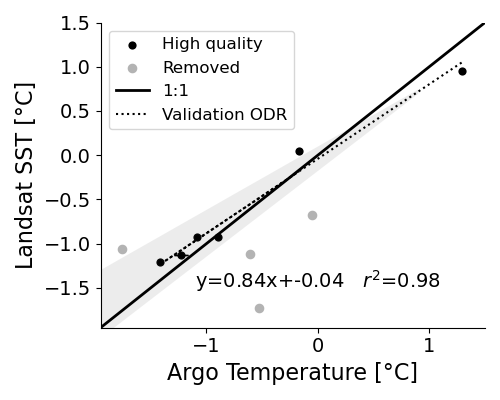

In [29]:
beta_mdn = [beta[0]-beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_mup = [beta[0]+beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_bdn = [beta[0]-beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
beta_bup = [beta[0]+beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
print(f'At 95% confidence interval: {np.around(beta[0],2)}+/-{np.around(beta_err[0]*1.96,2)}, {np.around(beta[1],2)}+/-{np.around(beta_err[1]*1.96,2)}, n={y_pred.shape[0]}')
xfill = np.array([-4.3,0.9])


# Plot data points and 1:1 line
fig, ax = plt.subplots(figsize=(5, 4))
ax.tick_params(labelsize=14)

xi = np.arange(-7.0,5.0,1.0)

# lower_err = abs(data['L8_SST'] - data['L8_SST_min'])  # distance to lower bound
# upper_err = abs(data['L8_SST_max'] - data['L8_SST'])  # distance to upper bound

ax.scatter(x_original,y_original,color='k',linewidth=0,s=35,label='High quality')
ax.errorbar(x_original,y_original,yerr=data['std'],color='k',fmt='o',ecolor='k',elinewidth=1,capthick=1,marker='o',ms=3,capsize=5,label='_no legend_')
# ax.errorbar(data['Argo_SST'],data['L8_SST'],yerr=[lower_err,upper_err],color='k',fmt='o',ecolor='k',elinewidth=1,capthick=1,marker='o',ms=3,capsize=5,label='_no legend_')
# ax.scatter(data['Argo_SST'],data['center'],color='r',linewidth=0,s=25,label='_no label_')
ax.scatter(rm['Argo_SST'],rm['L8_SST'],color='0.7', s=35, label='Removed',zorder=2)
ax.plot(xi,xi,color='k',linewidth=2, label='1:1')
ax.plot(x_original, y_pred, color='k', ls=':', label='Validation ODR')
ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill),alpha=0.1, facecolor='0.3')
# a1.plot(xi,xi*lreg.coef_[0]+lreg.intercept_[0],color='r',linewidth=2,label='RANSAC regression')
# a1.scatter(xC,yLC,color='r',linewidth=0,s=35,label='_no label_')
# a1.plot(xi,xi*resultC.params.L8_SST+resultC.params.Intercept,color='k',linewidth=2,label='OLS regression')
# a1.text(-2.1,-2.85,f'y={np.around(resultC.params.L8_SST,2)}x+{np.around(resultC.params.Intercept,2)}   p={p_val}',fontsize=12)
ax.text(-1.1,-1.5,f'y={np.around(beta[0],2)}x+{np.around(beta[1],2)}   $r^2$={np.around(R2,2)}',fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-1.95,1.5])
ax.set_xlim([-1.95,1.5])
ax.set_xlabel('Argo Temperature [°C]',fontsize=16)
ax.set_ylabel('Landsat SST [°C]',fontsize=16)
ax.legend(markerscale=1,fontsize=12,loc='upper left')

plt.tight_layout()
plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/argo_validation.pdf', format='pdf', dpi=500)
plt.show()

### Seal tag
Original location - L8_SST

In [39]:
# Remove low quality validation data from the valids data
rm_ids = [df_sealargo.seal_id[idx] for idx in rm_idx_argo]
rm = validmn_sealargo[validmn_sealargo.seal_id.isin(rm_ids)]
validmn_sealargo_clean = validmn_sealargo[~validmn_sealargo['seal_id'].isin(rm_ids)]
valids_sealargo_clean = valids_sealargo[~valids_sealargo['seal_id'].isin(rm_ids)]

In [40]:
# Orthoganal Regression 
# Keep only rows where L8_SST is NOT NaN
data = validmn_sealargo_clean
vcol = 'seal_SST'
lcol = 'L8_SST'
lstd = 'std'

# Original data
x_original = np.array(data[vcol])
y_original = np.array(data[lcol])

# Define a linear function for the model
def linear_model(p, x):
    return p[0] * x + p[1]

# Create a Model
linear = Model(linear_model)

# Create a RealData object using your DataFrame
mdata = RealData(x_original, y_original)

# Set up ODR with the model and data
odr = ODR(mdata, linear, beta0=[1., 0.])

# Run the regression
out = odr.run()

# Use the output
beta = out.beta
beta_err = out.sd_beta

# Print the summary
out.pprint()

# Predicting values using the ODR model
y_pred = linear_model(beta, x_original)

# Get R2
# Calculate Total Sum of Squares (SST)
y_mean = np.mean(y_original)
SST = np.sum((y_original - y_mean)**2)

# Calculate Residual Sum of Squares (SSR)
SSR = np.sum((y_original - y_pred)**2)

# Compute RMSE
rmse = np.sqrt(((y_original - y_pred) ** 2).mean())

# Calculate R^2
R2 = 1 - (SSR / SST)
print("R^2:", np.around(R2,2))
print(f"RMSE: {np.around(rmse,2)}")
print (f'n={data.shape[0]}')

Beta: [ 0.93428233 -0.14387121]
Beta Std Error: [0.08838706 0.11486195]
Beta Covariance: [[0.40636407 0.49576438]
 [0.49576438 0.6862626 ]]
Residual Variance: 0.0192248093656042
Inverse Condition #: 0.025316683515838143
Reason(s) for Halting:
  Sum of squares convergence
R^2: 0.82
RMSE: 0.18
n=23


At 95% confidence interval: 0.93+/-0.17, -0.14+/-0.23, n=23


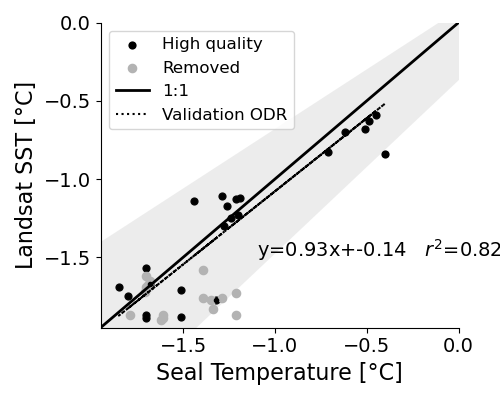

In [41]:
beta_mdn = [beta[0]-beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_mup = [beta[0]+beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_bdn = [beta[0]-beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
beta_bup = [beta[0]+beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
print(f'At 95% confidence interval: {np.around(beta[0],2)}+/-{np.around(beta_err[0]*1.96,2)}, {np.around(beta[1],2)}+/-{np.around(beta_err[1]*1.96,2)}, n={y_pred.shape[0]}')
xfill = np.array([-4.3,0.9])


# Plot data points and 1:1 line
fig, ax = plt.subplots(figsize=(5, 4))
ax.tick_params(labelsize=14)

xi = np.arange(-7.0,5.0,1.0)

# lower_err = abs(data['L8_SST'] - data['L8_SST_min'])  # distance to lower bound
# upper_err = abs(data['L8_SST_max'] - data['L8_SST'])  # distance to upper bound

ax.scatter(x_original,y_original,color='k',linewidth=0,s=35,label='High quality')
ax.errorbar(x_original,y_original,yerr=data[lstd],color='k',fmt='o',ecolor='k',elinewidth=1,capthick=1,marker='o',ms=3,capsize=5,label='_no legend_')
ax.scatter(rm[vcol],rm[lcol],color='0.7', s=35, label='Removed',zorder=2)
ax.plot(xi,xi,color='k',linewidth=2, label='1:1')
ax.plot(x_original, y_pred, color='k', ls=':', label='Validation ODR')
ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill),alpha=0.1, facecolor='0.3')
ax.text(-1.1,-1.5,f'y={np.around(beta[0],2)}x+{np.around(beta[1],2)}   $r^2$={np.around(R2,2)}',fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-1.95,0])
ax.set_xlim([-1.95,0])
ax.set_xlabel('Seal Temperature [°C]',fontsize=16)
ax.set_ylabel('Landsat SST [°C]',fontsize=16)
ax.legend(markerscale=1,fontsize=12,loc='upper left')

plt.tight_layout()
# plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/seal_validation.pdf', format='pdf', dpi=500)
plt.show()

Animotum location

In [42]:
# Remove low quality validation data from the valids data
rm_ids = [df_sealani.seal_id[idx] for idx in rm_idx_ani]
rm = validmn_sealani[validmn_sealani.seal_id.isin(rm_ids)]
validmn_sealani_clean = validmn_sealani[~validmn_sealani['seal_id'].isin(rm_ids)]
valids_sealani_clean = valids_sealani[~valids_sealani['seal_id'].isin(rm_ids)]

In [43]:
# Orthoganal Regression 
# Keep only rows where L8_SST is NOT NaN
data = validmn_sealani_clean
vcol = 'seal_SST'
lcol = 'L8_SST_ani'
lstd = 'std_ani'

# Original data
x_original = np.array(data[vcol])
y_original = np.array(data[lcol])

# Define a linear function for the model
def linear_model(p, x):
    return p[0] * x + p[1]

# Create a Model
linear = Model(linear_model)

# Create a RealData object using your DataFrame
mdata = RealData(x_original, y_original)

# Set up ODR with the model and data
odr = ODR(mdata, linear, beta0=[1., 0.])

# Run the regression
out = odr.run()

# Use the output
beta = out.beta
beta_err = out.sd_beta

# Print the summary
out.pprint()

# Predicting values using the ODR model
y_pred = linear_model(beta, x_original)

# Get R2
# Calculate Total Sum of Squares (SST)
y_mean = np.mean(y_original)
SST = np.sum((y_original - y_mean)**2)

# Calculate Residual Sum of Squares (SSR)
SSR = np.sum((y_original - y_pred)**2)

# Compute RMSE
rmse = np.sqrt(((y_original - y_pred) ** 2).mean())

# Calculate R^2
R2 = 1 - (SSR / SST)
print("R^2:", np.around(R2,2))
print(f"RMSE: {np.around(rmse,2)}")
print (f'n={data.shape[0]}')

Beta: [ 1.00390098 -0.0712067 ]
Beta Std Error: [0.10584798 0.13589283]
Beta Covariance: [[0.46766755 0.56375189]
 [0.56375189 0.77084158]]
Residual Variance: 0.02395675116440889
Inverse Condition #: 0.02558246271097164
Reason(s) for Halting:
  Sum of squares convergence
R^2: 0.79
RMSE: 0.21
n=22


At 95% confidence interval: 1.0+/-0.21, -0.07+/-0.27, n=22


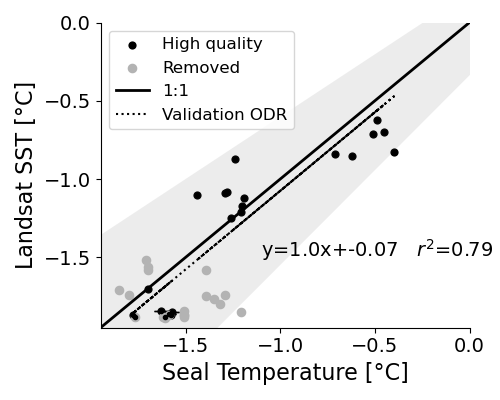

In [44]:
beta_mdn = [beta[0]-beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_mup = [beta[0]+beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_bdn = [beta[0]-beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
beta_bup = [beta[0]+beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
print(f'At 95% confidence interval: {np.around(beta[0],2)}+/-{np.around(beta_err[0]*1.96,2)}, {np.around(beta[1],2)}+/-{np.around(beta_err[1]*1.96,2)}, n={y_pred.shape[0]}')
xfill = np.array([-4.3,0.9])


# Plot data points and 1:1 line
fig, ax = plt.subplots(figsize=(5, 4))
ax.tick_params(labelsize=14)

xi = np.arange(-7.0,5.0,1.0)

ax.scatter(x_original,y_original,color='k',linewidth=0,s=35,label='High quality')
ax.errorbar(x_original,y_original,yerr=data[lstd],color='k',fmt='o',ecolor='k',elinewidth=1,capthick=1,marker='o',ms=3,capsize=5,label='_no legend_')
ax.scatter(rm[vcol],rm[lcol],color='0.7', s=35, label='Removed',zorder=2)
ax.plot(xi,xi,color='k',linewidth=2, label='1:1')
ax.plot(x_original, y_pred, color='k', ls=':', label='Validation ODR')
ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill),alpha=0.1, facecolor='0.3')
ax.text(-1.1,-1.5,f'y={np.around(beta[0],2)}x+{np.around(beta[1],2)}   $r^2$={np.around(R2,2)}',fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-1.95,0])
ax.set_xlim([-1.95,0])
ax.set_xlabel('Seal Temperature [°C]',fontsize=16)
ax.set_ylabel('Landsat SST [°C]',fontsize=16)
ax.legend(markerscale=1,fontsize=12,loc='upper left')

plt.tight_layout()
# plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/seal_validation.pdf', format='pdf', dpi=500)
plt.show()

All together

In [47]:
# Combine sealargo and sealani datasets: keep all sealargo, add only non-overlapping seal_ids from sealani
# Get seal_ids that are in sealargo
sealargo_ids = validmn_sealargo_clean['seal_id'].unique()

# Filter sealani to only include seal_ids NOT in sealargo
validmn_sealani_unique = validmn_sealani_clean[~validmn_sealani_clean['seal_id'].isin(sealargo_ids)]
valids_sealani_unique = valids_sealani_clean[~valids_sealani_clean['seal_id'].isin(sealargo_ids)]
valids_sealani_clean.shape[0] - valids_sealani_unique.shape[0]
# # Concatenate the datasets
# validmn_combined = pd.concat([validmn_sealargo_clean, validmn_sealani_unique], ignore_index=True)
# valids_combined = pd.concat([valids_sealargo_clean, valids_sealani_unique], ignore_index=True)

15

In [53]:
# Combine data from both datasets but keep track of source
# Create separate dataframes with source labels
df_argo = pd.DataFrame({
    'L8_SST': validmn_argo_clean['L8_SST'],
    'insitu_SST': validmn_argo_clean['Argo_SST'],
    'std': validmn_argo_clean['std'],
    'source': 'Argo'
})

df_seal = pd.DataFrame({
    'L8_SST': validmn_sealargo_clean['L8_SST'],
    'insitu_SST': validmn_sealargo_clean['seal_SST'],
    'std': validmn_sealargo_clean['std'],
    'loc_err[km]': validmn_sealargo_clean['loc_err[km]'],
    'source': 'Seal'
})

df_seal_ani = pd.DataFrame({
    'L8_SST': validmn_sealani_unique['L8_SST_ani'],
    'insitu_SST': validmn_sealani_unique['seal_SST'],
    'std': validmn_sealani_unique['std_ani'],
    # 'loc_err[km]': validmn_sealani_unique['loc_err[km]'],
    'source': 'Seal (Animotum)'
})

# Concatenate two datasets
data = pd.concat([df_argo, df_seal, df_seal_ani], ignore_index=True)
# data = pd.concat([df_argo, df_seal], ignore_index=True)
# data = pd.concat([df_argo, df_seal], ignore_index=True)

# Drop rows with NaN in either column
data = data.dropna(subset=['L8_SST', 'insitu_SST'], how='any')

# Original data
x_original = np.array(data['insitu_SST'])
y_original = np.array(data['L8_SST'])

# Define a linear function for the model
def linear_model(p, x):
    return p[0] * x + p[1]

# Create a Model
linear = Model(linear_model)

# Create a RealData object using your DataFrame
mdata = RealData(x_original, y_original)

# Set up ODR with the model and data
odr = ODR(mdata, linear, beta0=[1., 0.])

# Run the regression
out = odr.run()

# Use the output
beta = out.beta
beta_err = out.sd_beta

# Print the summary
out.pprint()

# Predicting values using the ODR model
y_pred = linear_model(beta, x_original)

# Get R2
# Calculate Total Sum of Squares (SST)
y_mean = np.mean(y_original)
SST = np.sum((y_original - y_mean)**2)

# Calculate Residual Sum of Squares (SSR)
SSR = np.sum((y_original - y_pred)**2)

# Compute RMSE
rmse = np.sqrt(((y_original - y_pred) ** 2).mean())

# Calculate R^2
R2 = 1 - (SSR / SST)
print("R^2:", np.around(R2,2))
print(f"RMSE: {np.around(rmse,2)}")
print (f'n={data.shape[0]}')

Beta: [ 0.9989719  -0.07553642]
Beta Std Error: [0.0542363  0.07284147]
Beta Covariance: [[0.14982815 0.17937754]
 [0.17937754 0.27025312]]
Residual Variance: 0.01963299905613966
Inverse Condition #: 0.03261001458503763
Reason(s) for Halting:
  Sum of squares convergence
R^2: 0.9
RMSE: 0.19
n=36


At 95% confidence interval: 1.0+/-0.11, -0.08+/-0.14, n=36


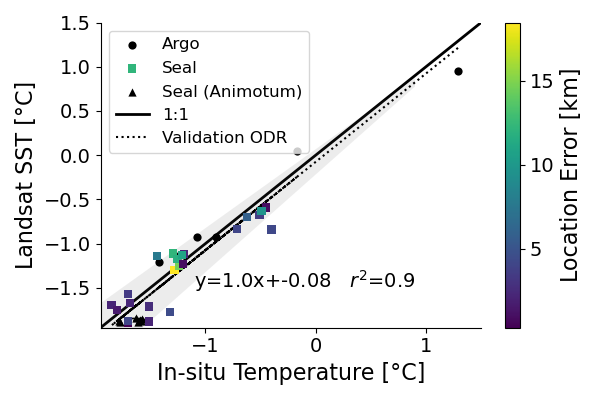

In [54]:
# Two datasets
beta_mdn = [beta[0]-beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_mup = [beta[0]+beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_bdn = [beta[0]-beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
beta_bup = [beta[0]+beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
print(f'At 95% confidence interval: {np.around(beta[0],2)}+/-{np.around(beta_err[0]*1.96,2)}, {np.around(beta[1],2)}+/-{np.around(beta_err[1]*1.96,2)}, n={y_pred.shape[0]}')
xfill = np.array([-4.3,0.9])

# Plot data points and 1:1 line
fig, ax = plt.subplots(figsize=(6, 4))
ax.tick_params(labelsize=14)
xi = np.arange(-7.0, 5.0, 1.0)

# Define markers for each dataset
markers = {'Argo': 'o', 'Seal': 's', 'Seal (Animotum)': '^'}

# Plot each dataset separately with different markers
for source, marker in markers.items():
    mask = data['source'] == source
    if mask.any():
        if (source=='Argo') | (source=='Seal (Animotum)'):
            ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                    yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
                    elinewidth=1, capthick=1, ms=3, capsize=5,zorder=1, 
                    label='_no legend_')
            ax.scatter(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                       c='k', linewidth=0, s=35, label=source, marker=marker, 
                       cmap='viridis', vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max(),zorder=2)
        elif source=='Seal':
            # ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
            #         yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
            #         elinewidth=1, capthick=1, ms=3, capsize=5, 
            #         label='_no legend_')
            ax.scatter(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                       c=data.loc[mask, 'loc_err[km]'], linewidth=0, s=35, label=source, marker=marker, 
                       cmap='viridis', vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max(),zorder=3)

# If you have removed data, you can add it here
# ax.scatter(rm['insitu_SST'], rm['L8_SST'], color='0.7', s=35, label='Removed', zorder=2)

ax.plot(xi, xi, color='k', linewidth=2, label='1:1',zorder=0)
ax.plot(x_original, y_pred, color='k', ls=':', label='Validation ODR')
ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill), 
                alpha=0.1, facecolor='0.3')

ax.text(-1.1, -1.5, f'y={np.around(beta[0], 2)}x+{np.around(beta[1], 2)}   $r^2$={np.around(R2, 2)}', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-1.95, 1.5])
ax.set_xlim([-1.95, 1.5])
ax.set_xlabel('In-situ Temperature [°C]', fontsize=16)
ax.set_ylabel('Landsat SST [°C]', fontsize=16)
ax.legend(markerscale=1, fontsize=12, loc='upper left')

# Create color bar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Location Error [km]', fontsize=16)

plt.tight_layout()
# plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/combined_validation.pdf', format='pdf', dpi=500)
plt.show()

In [27]:
**Calculate residual vs location error to show location error doesn't impact quality of measurement

Index(['L8_SST', 'insitu_SST', 'std', 'source', 'loc_err[km]'], dtype='object')

In [58]:
valids_argo_clean.index

Index(['2018-01-21 23:00:00', '2019-02-23 15:00:00', '2020-03-10 02:00:00',
       '2021-03-31 03:00:00', '2021-03-31 03:00:00', '2022-01-07 11:00:00',
       '2022-03-10 10:00:00'],
      dtype='object', name='DateTime')

In [ ]:
# Two datasets
beta_mdn = [beta[0]-beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_mup = [beta[0]+beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_bdn = [beta[0]-beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
beta_bup = [beta[0]+beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
print(f'At 95% confidence interval: {np.around(beta[0],2)}+/-{np.around(beta_err[0]*1.96,2)}, {np.around(beta[1],2)}+/-{np.around(beta_err[1]*1.96,2)}, n={y_pred.shape[0]}')
xfill = np.array([-4.3,0.9])

# Plot data points and 1:1 line
fig, ax = plt.subplots(figsize=(6, 4))
ax.tick_params(labelsize=14)
xi = np.arange(-7.0, 5.0, 1.0)

# Define markers for each dataset
markers = {'Argo': 'o', 'Seal': 's', 'Seal (Animotum)': '^'}

# Plot each dataset separately with different markers
for source, marker in markers.items():
    mask = data['source'] == source
    if mask.any():
        if (source=='Argo') | (source=='Seal (Animotum)'):
            ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                    yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
                    elinewidth=1, capthick=1, ms=3, capsize=5,zorder=1, 
                    label='_no legend_')
            ax.scatter(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                       c='k', linewidth=0, s=35, label=source, marker=marker, 
                       cmap='viridis', vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max(),zorder=2)
        elif source=='Seal':
            # ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
            #         yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
            #         elinewidth=1, capthick=1, ms=3, capsize=5, 
            #         label='_no legend_')
            ax.scatter(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                       c=data.loc[mask, 'loc_err[km]'], linewidth=0, s=35, label=source, marker=marker, 
                       cmap='viridis', vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max(),zorder=3)

# If you have removed data, you can add it here
# ax.scatter(rm['insitu_SST'], rm['L8_SST'], color='0.7', s=35, label='Removed', zorder=2)

ax.plot(xi, xi, color='k', linewidth=2, label='1:1',zorder=0)
ax.plot(x_original, y_pred, color='k', ls=':', label='Validation ODR')
ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill), 
                alpha=0.1, facecolor='0.3')

ax.text(-1.1, -1.5, f'y={np.around(beta[0], 2)}x+{np.around(beta[1], 2)}   $r^2$={np.around(R2, 2)}', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-1.95, 1.5])
ax.set_xlim([-1.95, 1.5])
ax.set_xlabel('In-situ Temperature [°C]', fontsize=16)
ax.set_ylabel('Landsat SST [°C]', fontsize=16)
ax.legend(markerscale=1, fontsize=12, loc='upper left')

# Create color bar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Location Error [km]', fontsize=16)

plt.tight_layout()
# plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/combined_validation.pdf', format='pdf', dpi=500)
plt.show()

In [163]:
# Concatenate all datasets
data = pd.concat([df_argo, df_seal, df_seal_ani], ignore_index=True)

# Drop rows with NaN in either column
data = data.dropna(subset=['L8_SST', 'insitu_SST'], how='any')

# Original data
x_original = np.array(data['insitu_SST'])
y_original = np.array(data['L8_SST'])

# Define a linear function for the model
def linear_model(p, x):
    return p[0] * x + p[1]

# Create a Model
linear = Model(linear_model)

# Create a RealData object using your DataFrame
mdata = RealData(x_original, y_original)

# Set up ODR with the model and data
odr = ODR(mdata, linear, beta0=[1., 0.])

# Run the regression
out = odr.run()

# Use the output
beta = out.beta
beta_err = out.sd_beta

# Print the summary
out.pprint()

# Predicting values using the ODR model
y_pred = linear_model(beta, x_original)

# Get R2
# Calculate Total Sum of Squares (SST)
y_mean = np.mean(y_original)
SST = np.sum((y_original - y_mean)**2)

# Calculate Residual Sum of Squares (SSR)
SSR = np.sum((y_original - y_pred)**2)

# Compute RMSE
rmse = np.sqrt(((y_original - y_pred) ** 2).mean())

# Calculate R^2
R2 = 1 - (SSR / SST)
print("R^2:", np.around(R2,2))
print(f"RMSE: {np.around(rmse,2)}")
print (f'n={data.shape[0]}')

Beta: [ 0.96324602 -0.09725566]
Beta Std Error: [0.05032809 0.06390715]
Beta Covariance: [[0.1199817  0.13666144]
 [0.13666144 0.19346078]]
Residual Variance: 0.021110860922200464
Inverse Condition #: 0.03353578686857255
Reason(s) for Halting:
  Sum of squares convergence
R^2: 0.87
RMSE: 0.2
n=51


At 95% confidence interval: 0.96+/-0.1, -0.1+/-0.13, n=51


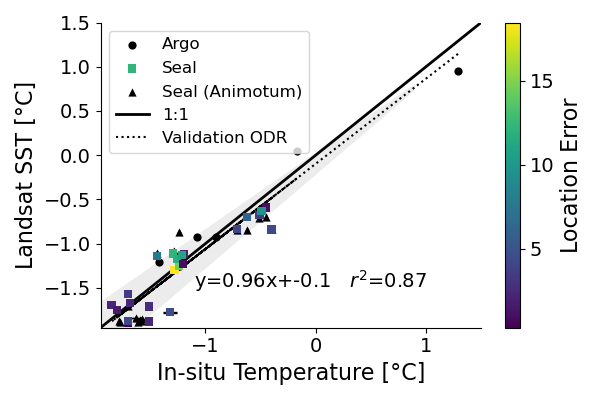

In [165]:
# All three together
beta_mdn = [beta[0]-beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_mup = [beta[0]+beta_err[0]*1.96,beta[1]-beta_err[1]*1.96]
beta_bdn = [beta[0]-beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
beta_bup = [beta[0]+beta_err[0]*1.96,beta[1]+beta_err[1]*1.96]
print(f'At 95% confidence interval: {np.around(beta[0],2)}+/-{np.around(beta_err[0]*1.96,2)}, {np.around(beta[1],2)}+/-{np.around(beta_err[1]*1.96,2)}, n={y_pred.shape[0]}')
xfill = np.array([-4.3,0.9])

# Plot data points and 1:1 line
fig, ax = plt.subplots(figsize=(6, 4))
ax.tick_params(labelsize=14)
xi = np.arange(-7.0, 5.0, 1.0)

# Define markers for each dataset
markers = {'Argo': 'o', 'Seal': 's', 'Seal (Animotum)': '^'}

# Plot each dataset separately with different markers
for source, marker in markers.items():
    mask = data['source'] == source
    if mask.any():
        if (source=='Argo') | (source=='Seal (Animotum)'):
            ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                    yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
                    elinewidth=1, capthick=1, ms=3, capsize=5,zorder=1, 
                    label='_no legend_')
            ax.scatter(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                       c='k', linewidth=0, s=35, label=source, marker=marker, 
                       cmap='viridis', vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max(),zorder=2)
        elif source=='Seal':
            ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                    yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
                    elinewidth=1, capthick=1, ms=3, capsize=5, 
                    label='_no legend_',zorder=2)
            ax.scatter(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                       c=data.loc[mask, 'loc_err[km]'], linewidth=0, s=35, label=source, marker=marker, 
                       cmap='viridis', vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max(),zorder=3)

# If you have removed data, you can add it here
# ax.scatter(rm['insitu_SST'], rm['L8_SST'], color='0.7', s=35, label='Removed', zorder=2)

ax.plot(xi, xi, color='k', linewidth=2, label='1:1',zorder=0)
ax.plot(x_original, y_pred, color='k', ls=':', label='Validation ODR')
ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill), 
                alpha=0.1, facecolor='0.3')

ax.text(-1.1, -1.5, f'y={np.around(beta[0], 2)}x+{np.around(beta[1], 2)}   $r^2$={np.around(R2, 2)}', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-1.95, 1.5])
ax.set_xlim([-1.95, 1.5])
ax.set_xlabel('In-situ Temperature [°C]', fontsize=16)
ax.set_ylabel('Landsat SST [°C]', fontsize=16)
ax.legend(markerscale=1, fontsize=12, loc='upper left')

# Create color bar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Location Error', fontsize=16)

plt.tight_layout()
# plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/combined_validation.pdf', format='pdf', dpi=500)
plt.show()